<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/AI_Workforce_%26_Automation_Dataset_(2015%E2%80%932025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Workforce & Automation Dataset (2015–2025)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

# About the dataset

Dataset Overview: This dataset, 'AI Workforce & Automation (2015-2025)', contains 220 entries representing annual data from 2015 to 2025 across 20 different countries. Each country has 11 years of data, indicating a balanced representation. The dataset includes a variety of metrics related to AI's impact on the workforce, such as AI_Investment_BillionUSD, Automation_Rate_Percent, Employment_Rate_Percent, Average_Salary_USD, Job_Displacement_Million, Job_Creation_Million, and AI_Readiness_Score, among others. There are no missing values or duplicate entries, ensuring data quality.

Key Insights from EDA:

Variable Distributions: Histograms showed varied distributions for numerical features. For instance, AI_Investment_BillionUSD and Reskilling_Investment_MillionUSD appear to be right-skewed, suggesting a range from lower to higher values with a concentration towards the lower end for most observations. Other variables like Automation_Rate_Percent and Employment_Rate_Percent show more spread out or somewhat normal-like distributions.
Country-Specific Trends: While not explicitly detailed in the univariate analysis (beyond showing equal counts for each country), the box plots revealed how various numerical metrics differ across countries over the years, hinting at potential country-specific strategies or impacts of AI.
Correlations (from Heatmap):
There is a strong positive correlation between AI_Investment_BillionUSD and Reskilling_Investment_MillionUSD, suggesting countries investing more in AI also tend to invest more in reskilling their workforce.
Automation_Rate_Percent shows a positive correlation with AI_Investment_BillionUSD and Reskilling_Investment_MillionUSD, which is expected. Its relationship with Employment_Rate_Percent and Job_Displacement_Million would be crucial for further investigation into AI's impact on employment.
Productivity_Index shows positive correlations with AI_Investment_BillionUSD, Automation_Rate_Percent, and Average_Salary_USD, implying that increased AI adoption and investment are associated with higher productivity and wages.
Job_Creation_Million has a moderate positive correlation with AI_Investment_BillionUSD, suggesting that AI investments are also associated with new job opportunities, potentially offsetting some job displacement. Conversely, Job_Displacement_Million also shows some positive correlation with AI_Investment_BillionUSD.
Overall, the dataset provides a rich ground for analyzing the multifaceted impact of AI and automation on global workforces, with initial insights pointing towards a complex interplay between investment, automation, productivity, and employment dynamics.

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d emirhanakku/ai-workforce-and-automation-dataset-20152025

# Unziping the downloaded file
!unzip ai-workforce-and-automation-dataset-20152025.zip


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/emirhanakku/ai-workforce-and-automation-dataset-20152025
License(s): other
  0% 0.00/7.24k [00:00<?, ?B/s]
100% 7.24k/7.24k [00:00<00:00, 28.2MB/s]
Archive:  ai-workforce-and-automation-dataset-20152025.zip
  inflating: global_ai_workforce_automation_2015_2025.csv  


In [5]:
df = pd.read_csv('global_ai_workforce_automation_2015_2025.csv')
df.head(11)

,Year,Country,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
0,2015,United States,52.46,10.75,65.50,38392.64,65.78,709.03,0.64,0.19,0.14,47.87
1,2016,United States,60.64,11.64,65.25,39371.74,67.02,815.38,0.75,0.16,0.85,43.85
2,2017,United States,66.11,12.46,64.93,40772.29,68.51,921.74,0.51,0.17,1.23,37.13
3,2018,United States,72.45,13.35,64.84,43974.92,71.09,1028.09,0.69,0.27,0.76,42.28
4,2019,United States,79.11,14.65,64.55,43745.39,69.89,1134.45,0.57,0.25,0.85,43.95
5,2020,United States,84.92,15.12,63.05,46695.82,74.53,1240.80,0.66,0.34,1.59,51.47
6,2021,United States,89.44,16.02,64.22,45248.01,73.64,1347.16,0.72,0.15,0.88,48.62
7,2022,United States,96.00,18.60,63.94,51724.35,77.10,1453.51,0.52,0.11,0.21,49.00
8,2023,United States,104.62,19.48,62.05,45217.73,76.07,1559.86,0.37,0.05,1.12,41.24
9,2024,United States,111.07,20.25,61.31,50198.31,75.64,1666.22,0.76,0.37,2.59,51.52


In [6]:
df.tail(11)

,Year,Country,AI_Investment_BillionUSD,Automation_Rate_Percent,Employment_Rate_Percent,Average_Salary_USD,Productivity_Index,Reskilling_Investment_MillionUSD,AI_Policy_Index,Job_Displacement_Million,Job_Creation_Million,AI_Readiness_Score
209,2015,Mexico,73.69,36.12,65.97,63336.97,61.31,237.56,0.56,0.75,1.18,40.90
210,2016,Mexico,80.49,37.05,65.53,65948.38,62.94,273.19,0.18,0.17,0.90,37.76
211,2017,Mexico,89.43,37.89,65.21,68666.13,64.91,308.82,0.72,0.89,1.79,49.15
212,2018,Mexico,100.43,39.46,65.26,69473.78,66.33,344.46,0.78,0.60,0.72,50.48
213,2019,Mexico,108.04,39.36,65.14,74725.19,66.19,380.09,0.31,0.53,1.12,46.81
214,2020,Mexico,116.55,40.97,63.66,77669.49,67.06,415.72,0.57,0.52,0.67,44.18
215,2021,Mexico,127.24,42.11,63.98,79254.28,70.99,451.36,0.81,0.20,2.43,50.84
216,2022,Mexico,136.15,43.56,62.56,73121.34,68.63,486.99,0.45,0.30,3.73,44.61
217,2023,Mexico,143.04,44.95,63.29,85277.56,69.73,522.62,0.47,0.57,0.42,43.53
218,2024,Mexico,154.40,43.82,62.73,81767.76,72.81,558.26,0.64,0.63,4.36,47.60


In [7]:
df.shape

(220, 12)

In [8]:
df.columns

Index(['Year', 'Country', 'AI_Investment_BillionUSD',
       'Automation_Rate_Percent', 'Employment_Rate_Percent',
       'Average_Salary_USD', 'Productivity_Index',
       'Reskilling_Investment_MillionUSD', 'AI_Policy_Index',
       'Job_Displacement_Million', 'Job_Creation_Million',
       'AI_Readiness_Score'],
      dtype='object')

In [9]:
df.dtypes

,0
Year,int64
Country,object
AI_Investment_BillionUSD,float64
Automation_Rate_Percent,float64
Employment_Rate_Percent,float64
Average_Salary_USD,float64
Productivity_Index,float64
Reskilling_Investment_MillionUSD,float64
AI_Policy_Index,float64
Job_Displacement_Million,float64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              220 non-null    int64  
 1   Country                           220 non-null    object 
 2   AI_Investment_BillionUSD          220 non-null    float64
 3   Automation_Rate_Percent           220 non-null    float64
 4   Employment_Rate_Percent           220 non-null    float64
 5   Average_Salary_USD                220 non-null    float64
 6   Productivity_Index                220 non-null    float64
 7   Reskilling_Investment_MillionUSD  220 non-null    float64
 8   AI_Policy_Index                   220 non-null    float64
 9   Job_Displacement_Million          220 non-null    float64
 10  Job_Creation_Million              220 non-null    float64
 11  AI_Readiness_Score                220 non-null    float64
dtypes: float

In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,220.0,NaN,NaN,NaN,2020.0,3.169489,2015.0,2017.0,2020.0,2023.0,2025.0
Country,220,20,United States,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AI_Investment_BillionUSD,220.0,NaN,NaN,NaN,82.364409,42.522535,5.4,47.6425,81.375,114.48,177.29
Automation_Rate_Percent,220.0,NaN,NaN,NaN,27.352136,8.860064,10.19,20.3375,27.085,33.8125,48.41
Employment_Rate_Percent,220.0,NaN,NaN,NaN,68.818909,5.833969,57.12,63.9625,68.8,73.7525,79.95
Average_Salary_USD,220.0,NaN,NaN,NaN,62074.483818,19472.117474,26787.83,45251.79,60828.005,75538.9975,117335.31
Productivity_Index,220.0,NaN,NaN,NaN,60.6145,11.09393,40.4,51.8325,59.005,69.6775,87.26
Reskilling_Investment_MillionUSD,220.0,NaN,NaN,NaN,939.959682,522.835431,141.24,520.2075,881.575,1278.685,2371.55
AI_Policy_Index,220.0,NaN,NaN,NaN,0.6045,0.164123,0.18,0.48,0.62,0.7225,1.0
Job_Displacement_Million,220.0,NaN,NaN,NaN,0.365636,0.220901,0.02,0.1875,0.35,0.52,1.01


In [13]:
df.isnull().sum()

,0
Year,0
Country,0
AI_Investment_BillionUSD,0
Automation_Rate_Percent,0
Employment_Rate_Percent,0
Average_Salary_USD,0
Productivity_Index,0
Reskilling_Investment_MillionUSD,0
AI_Policy_Index,0
Job_Displacement_Million,0


In [14]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

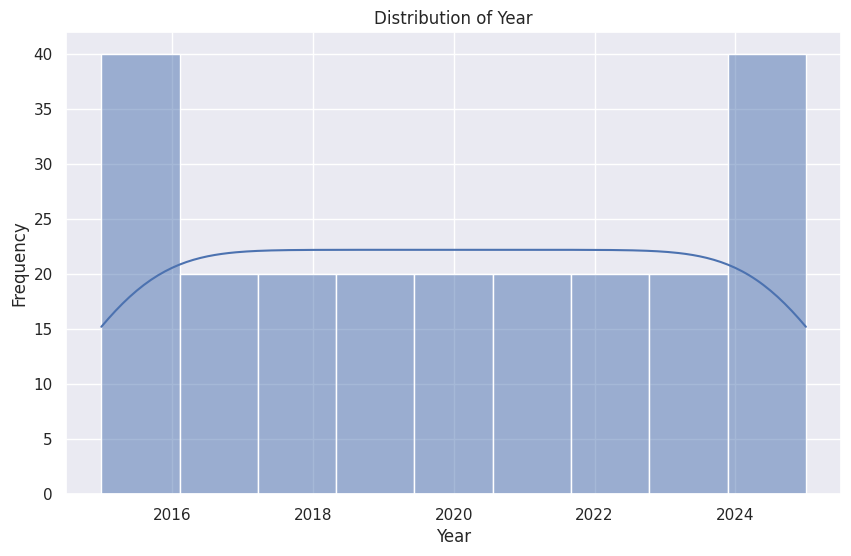

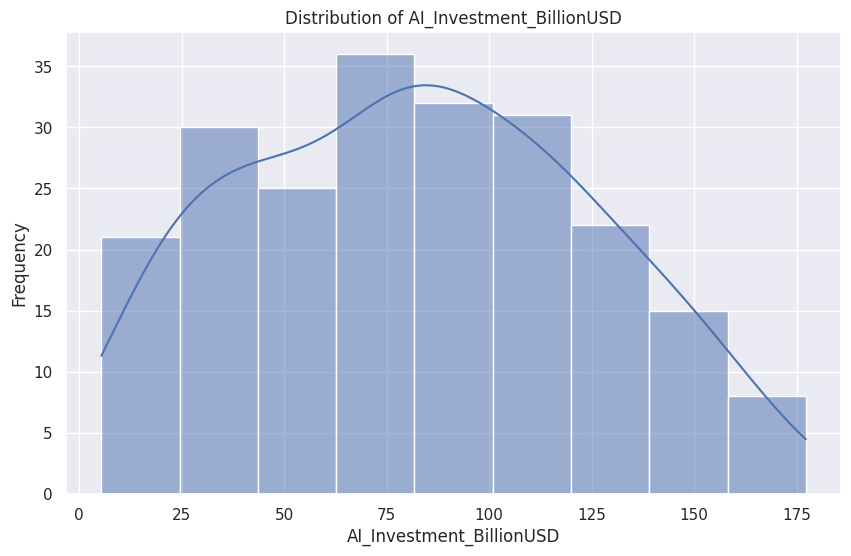

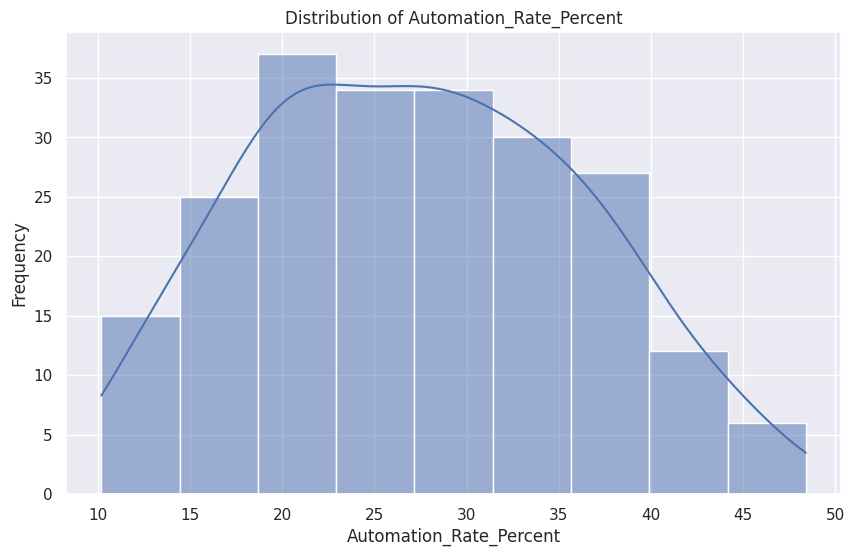

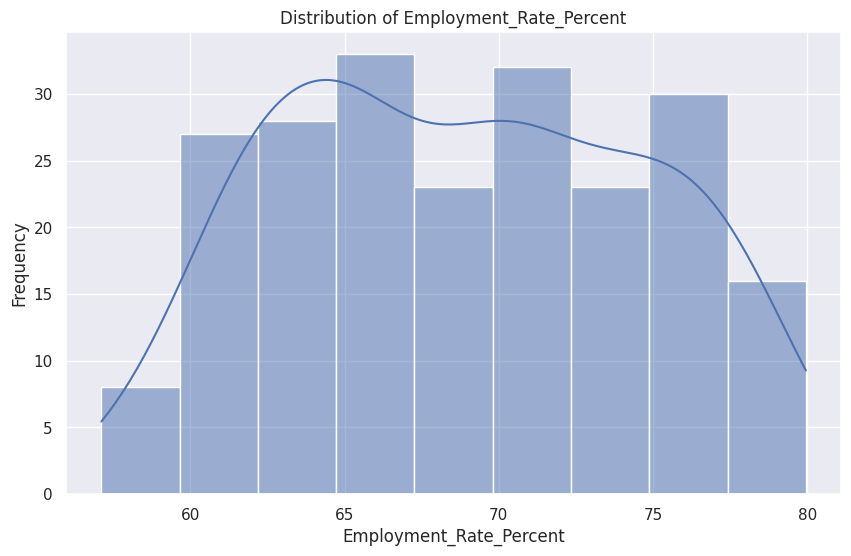

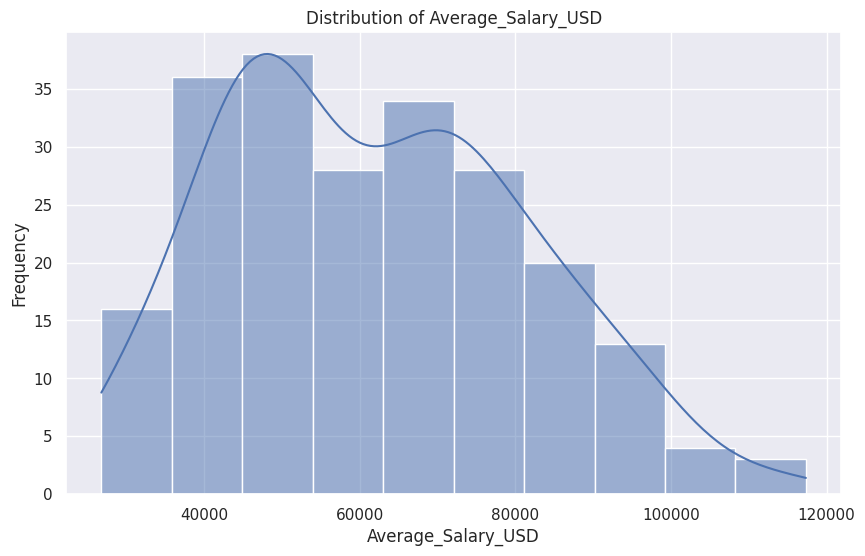

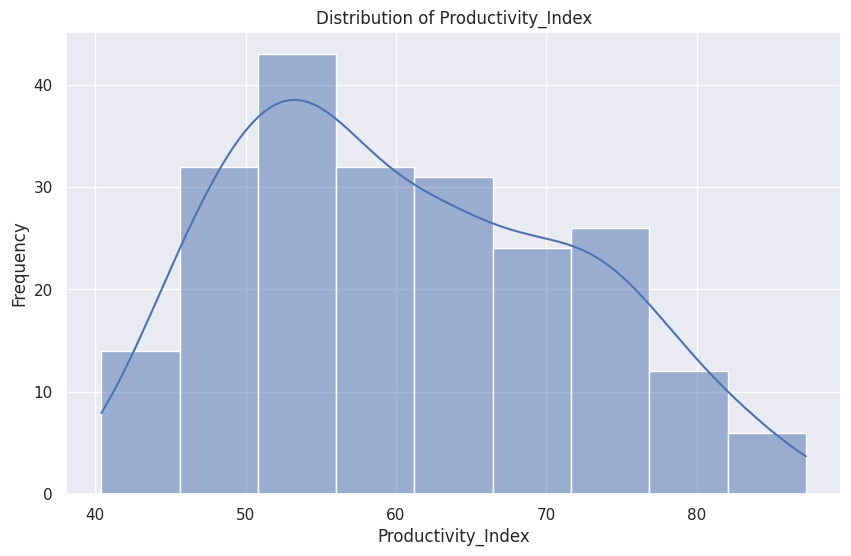

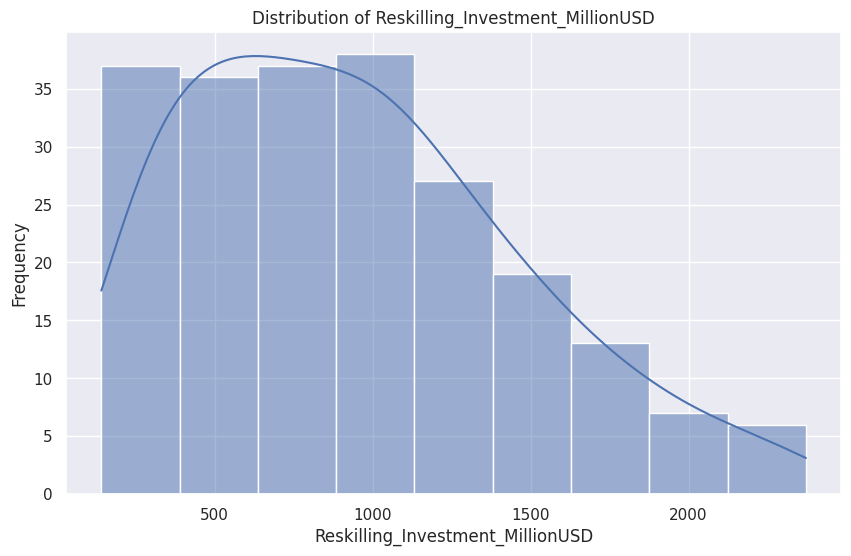

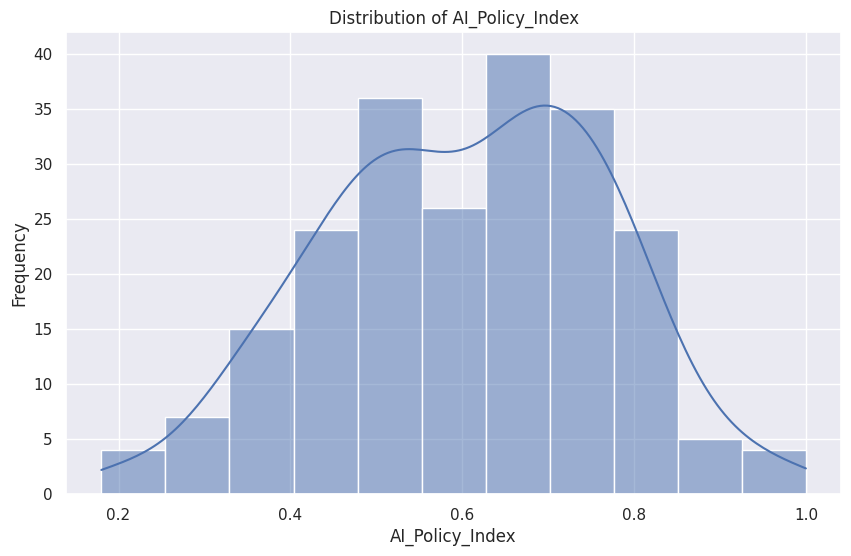

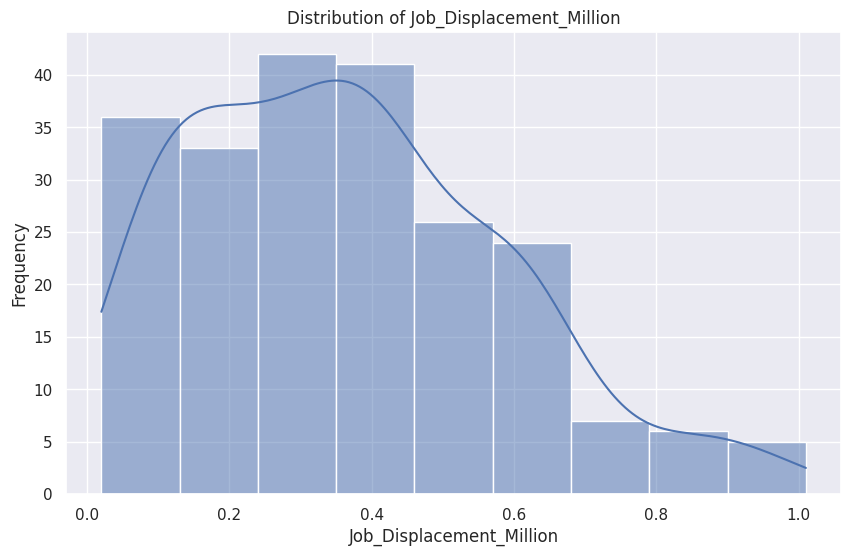

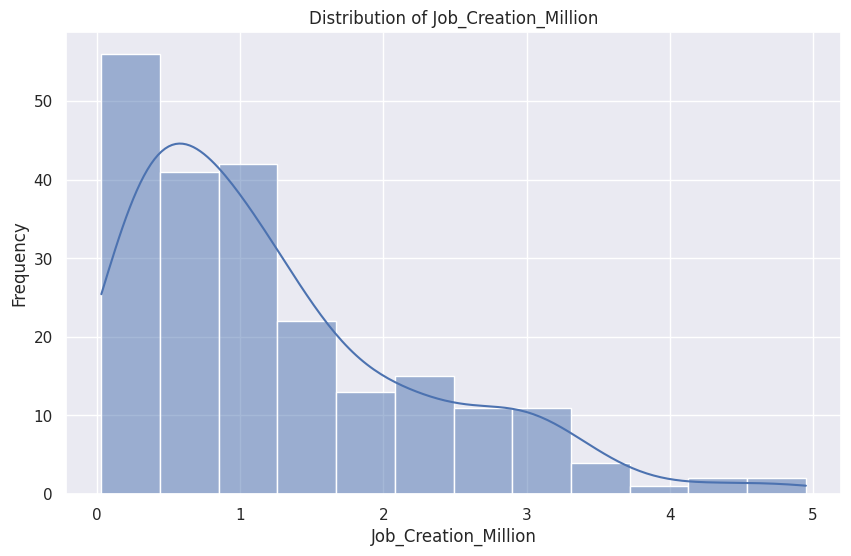

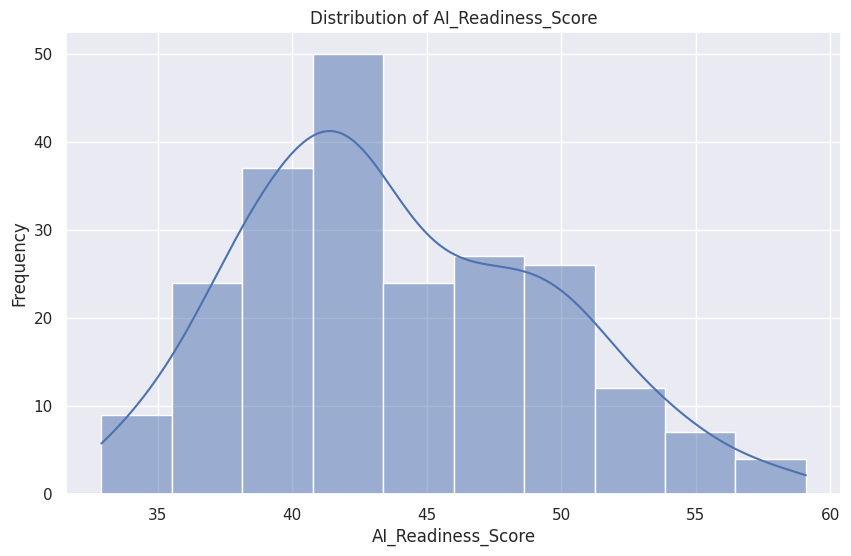

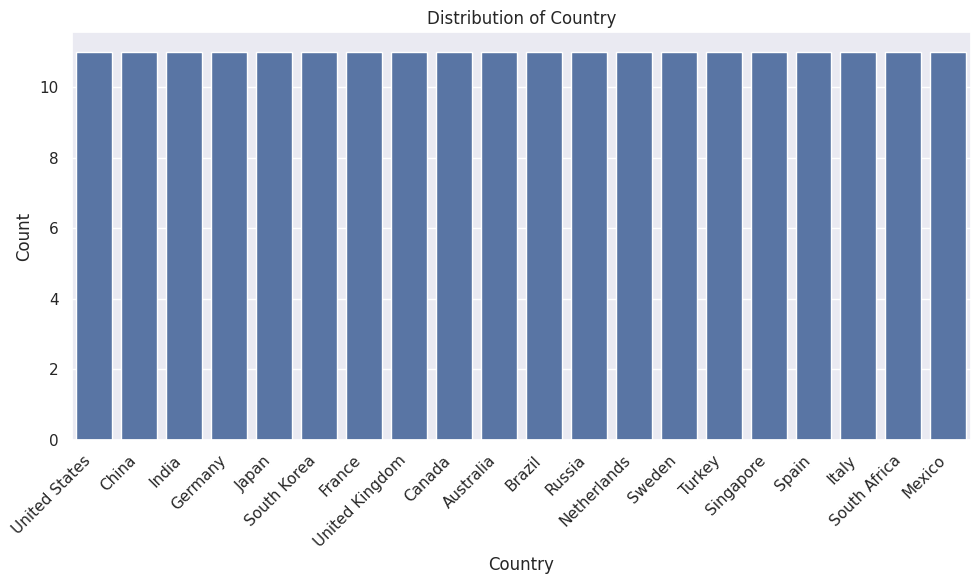

Value counts for Country:
Country
United States     11
China             11
India             11
Germany           11
Japan             11
South Korea       11
France            11
United Kingdom    11
Canada            11
Australia         11
Brazil            11
Russia            11
Netherlands       11
Sweden            11
Turkey            11
Singapore         11
Spain             11
Italy             11
South Africa      11
Mexico            11
Name: count, dtype: int64



In [16]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

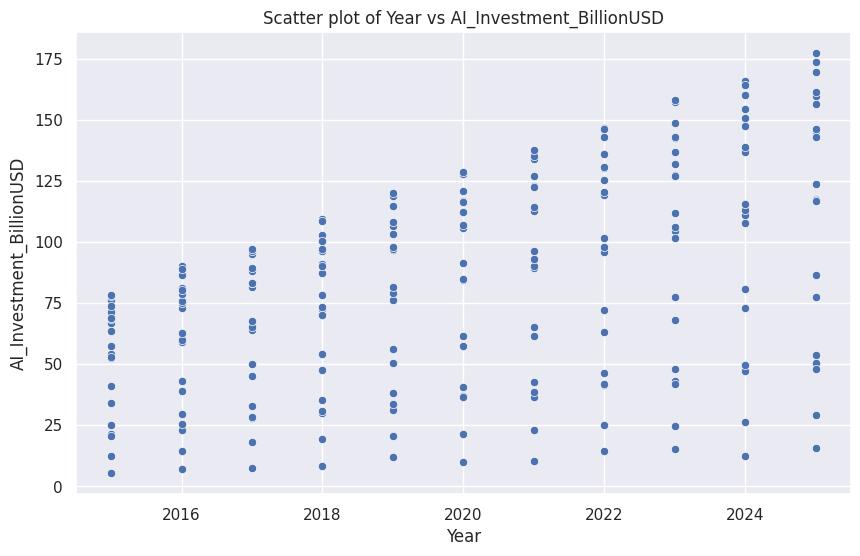

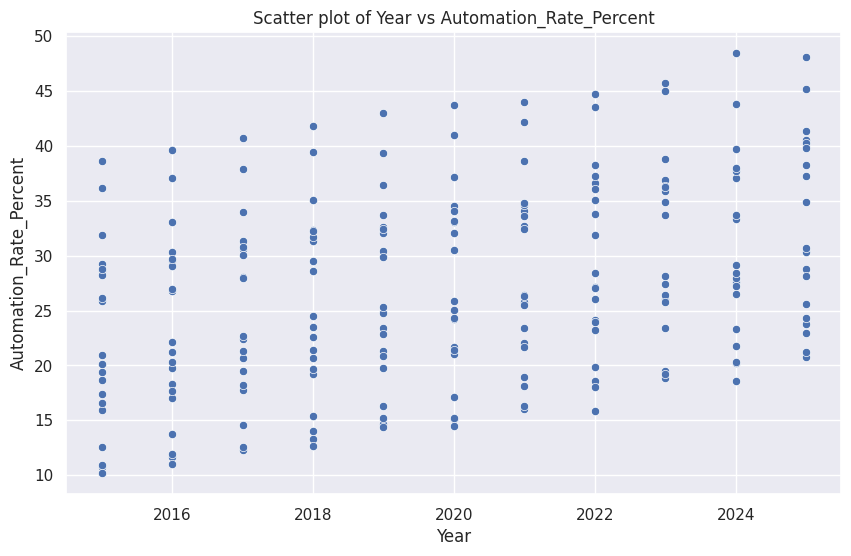

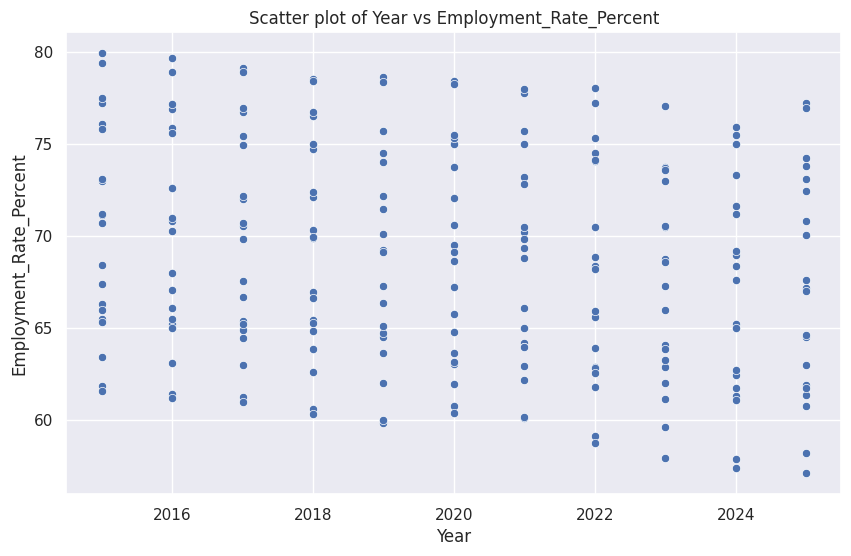

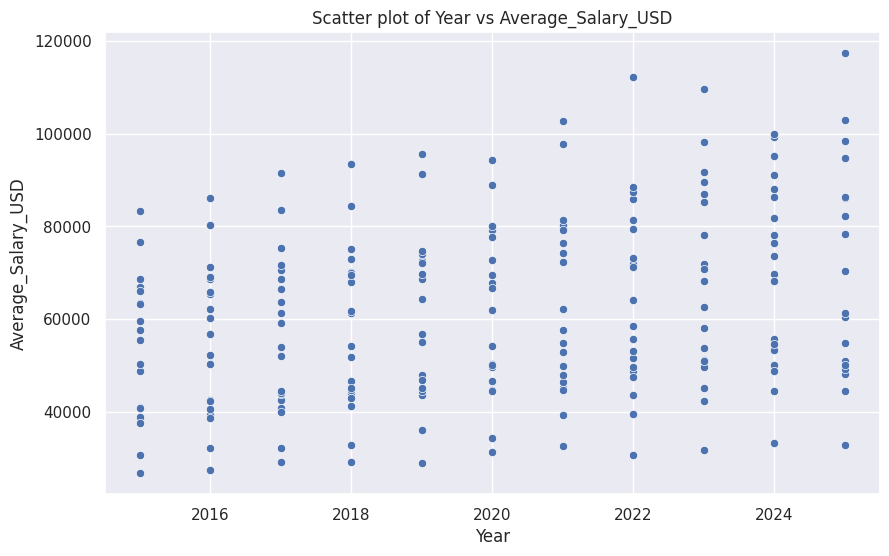

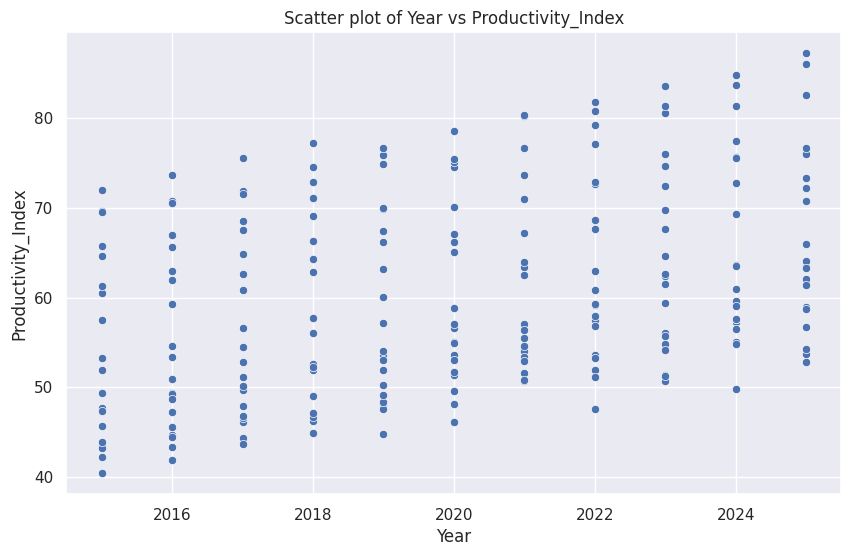

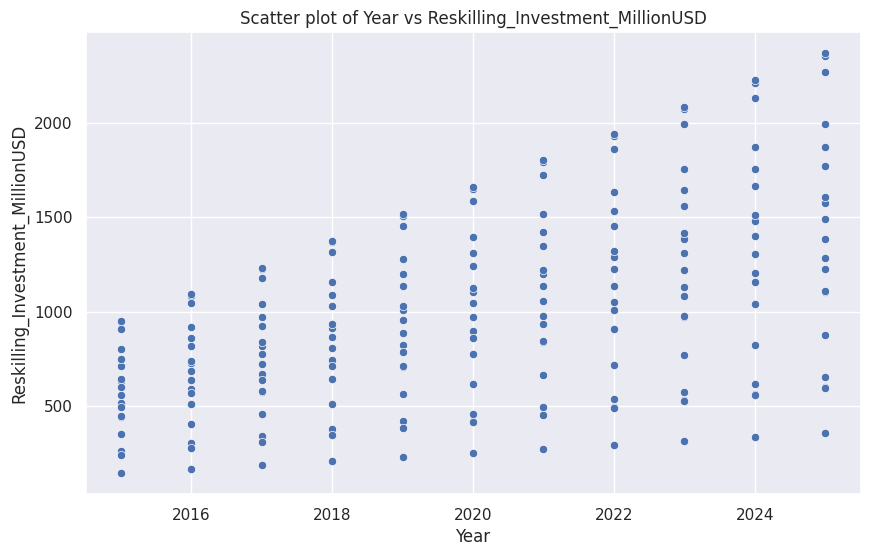

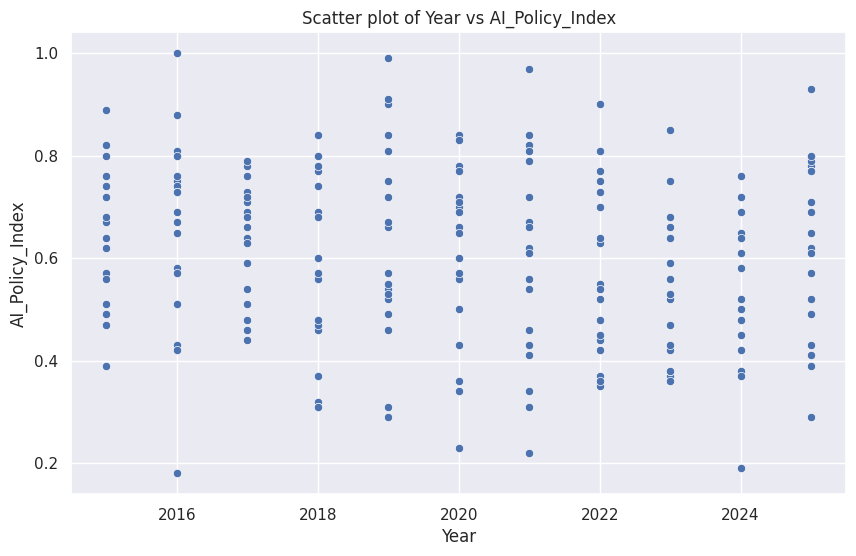

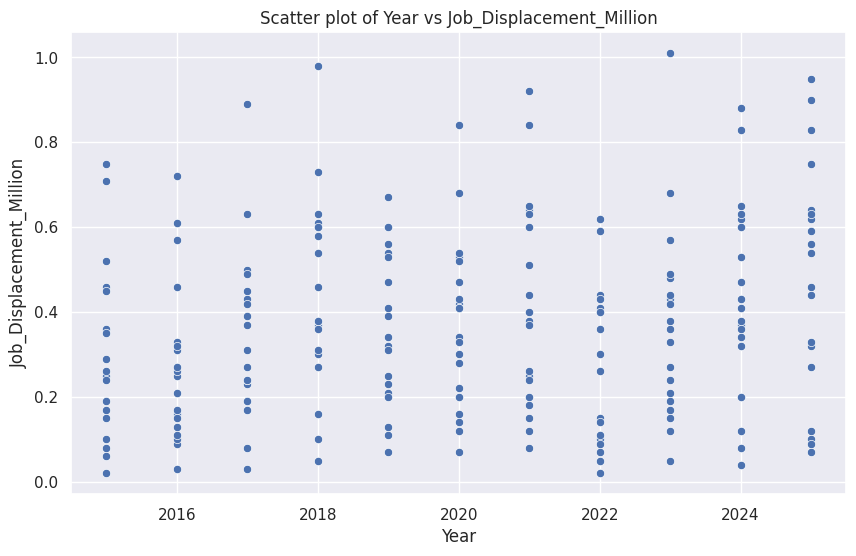

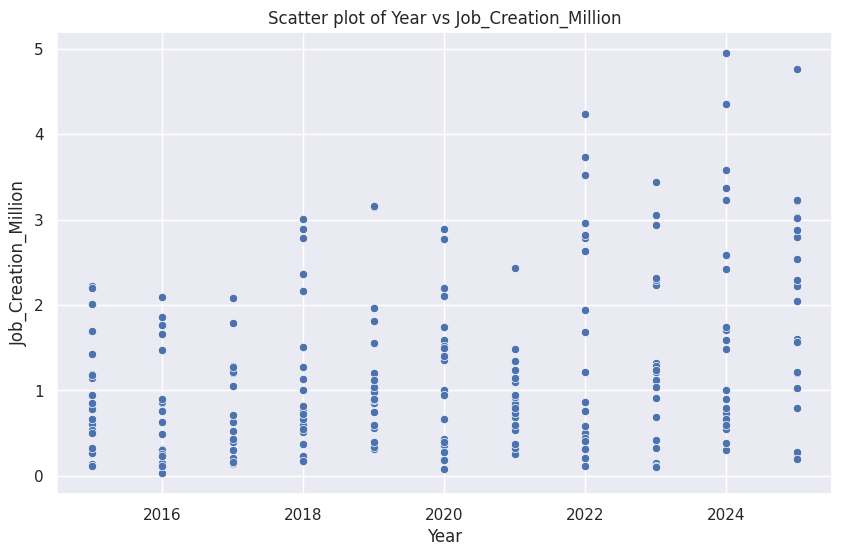

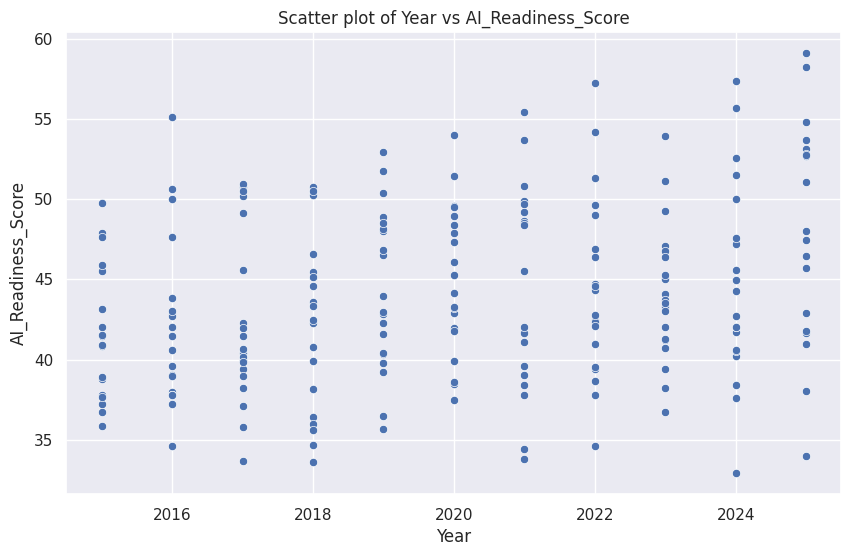

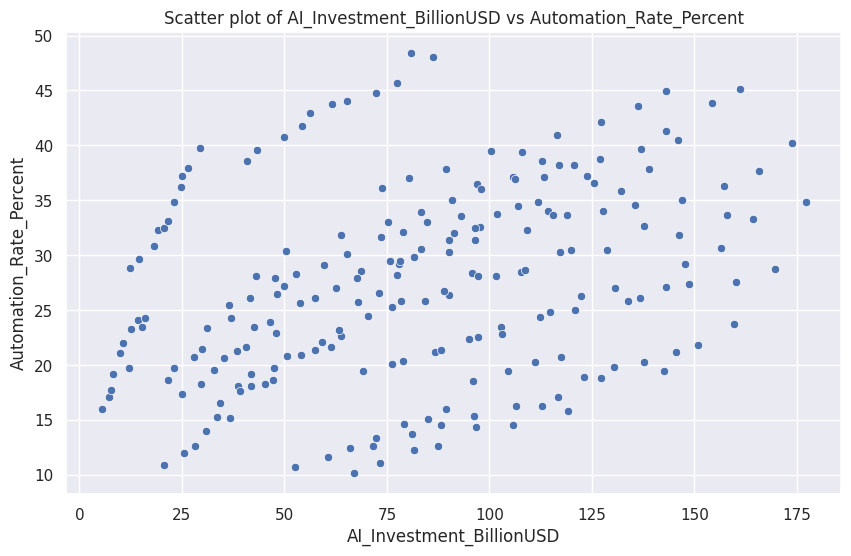

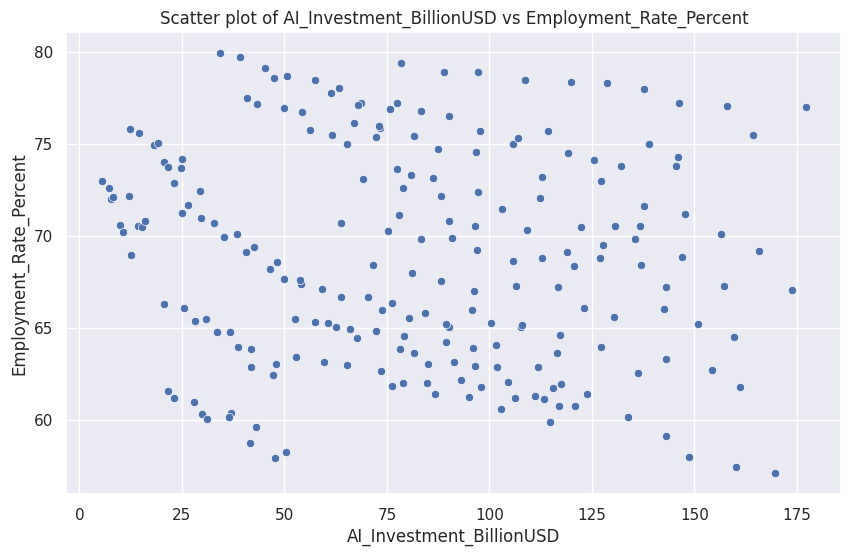

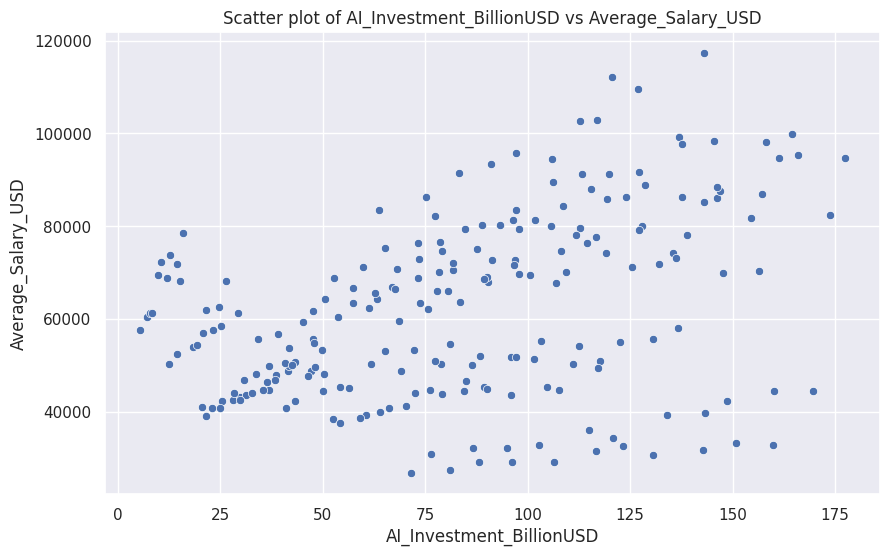

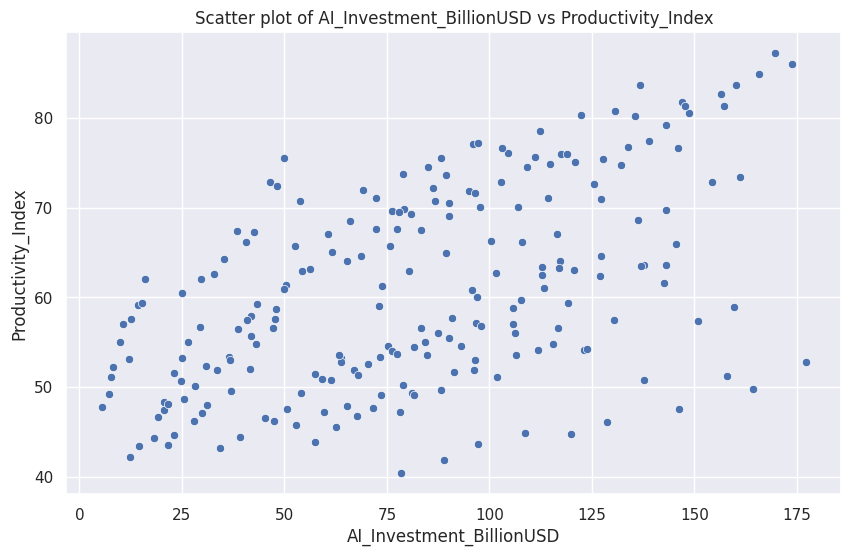

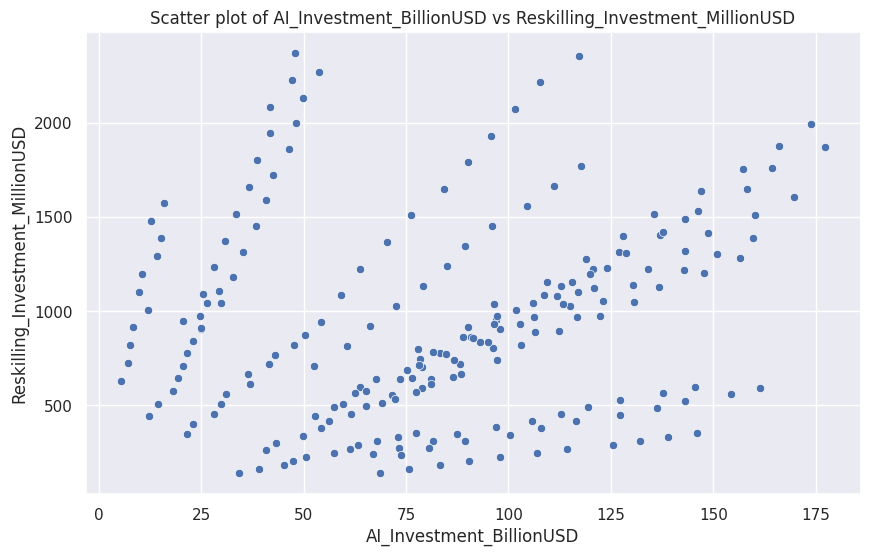

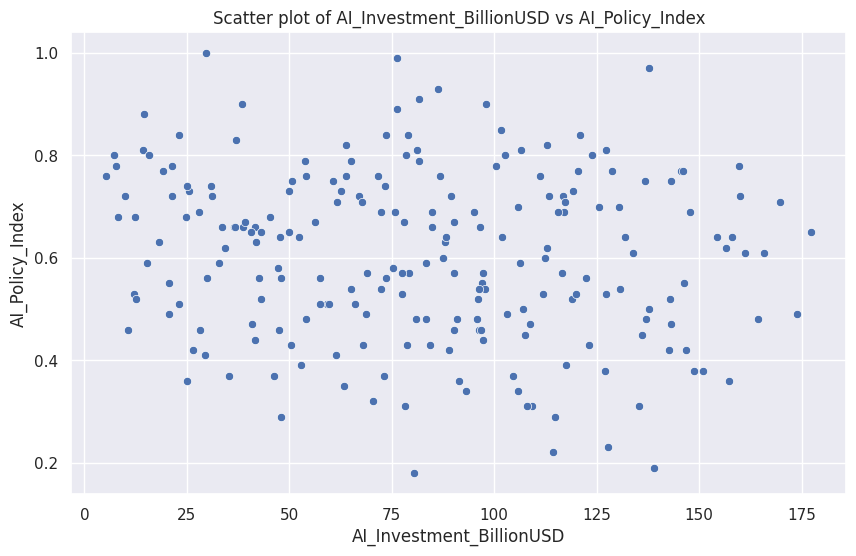

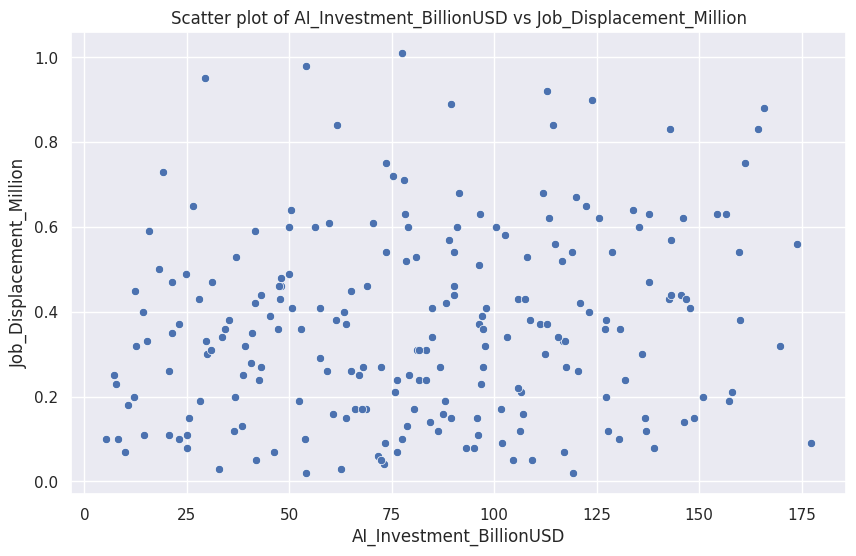

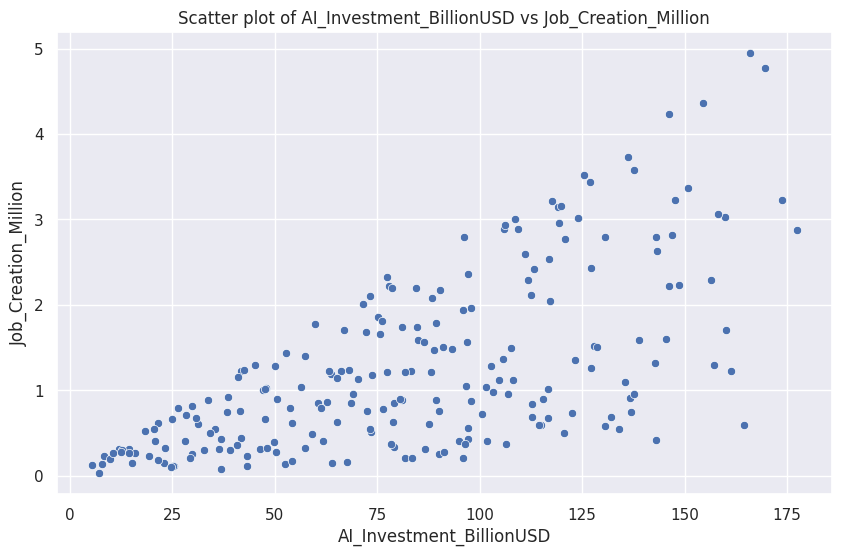

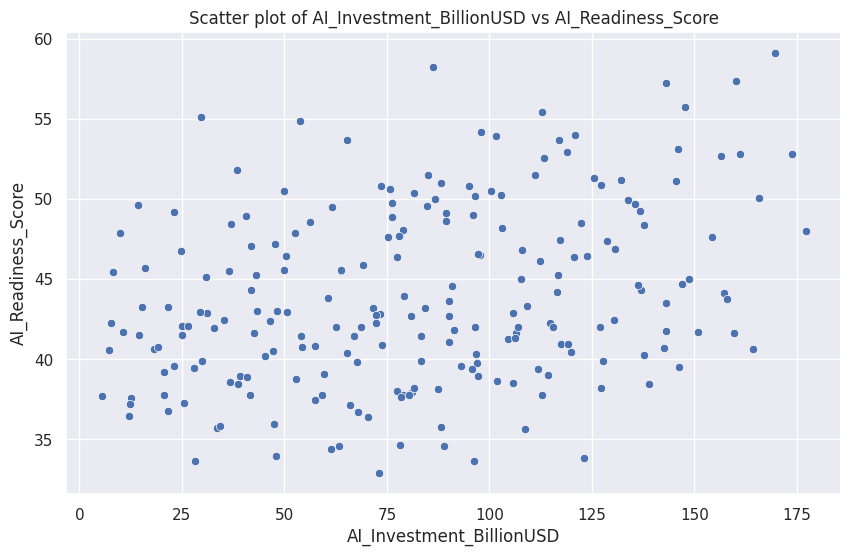

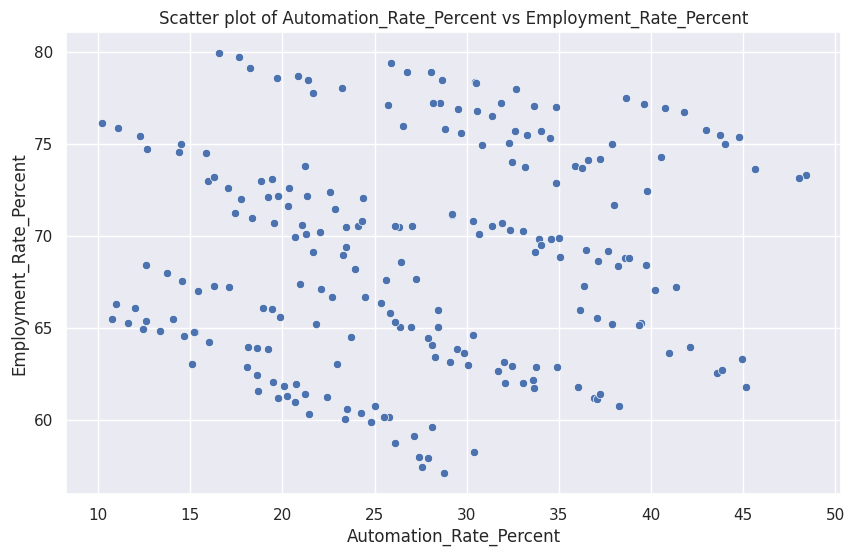

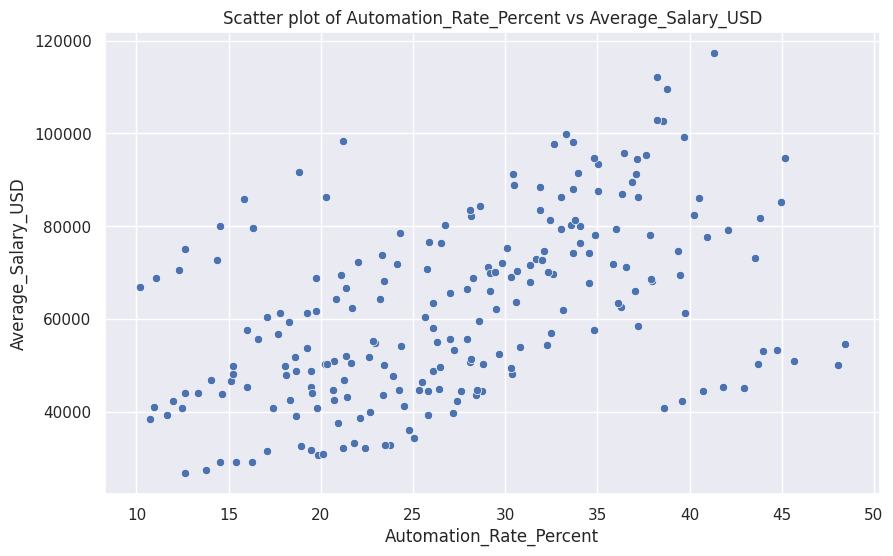

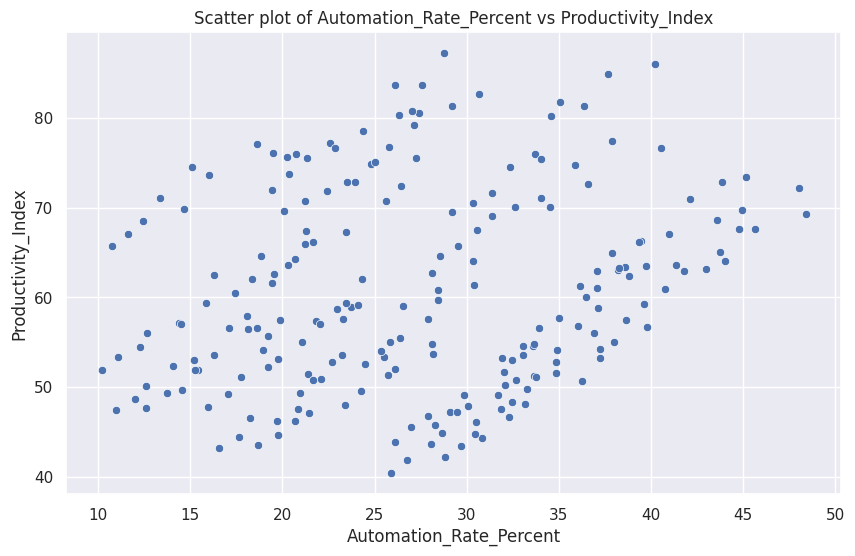

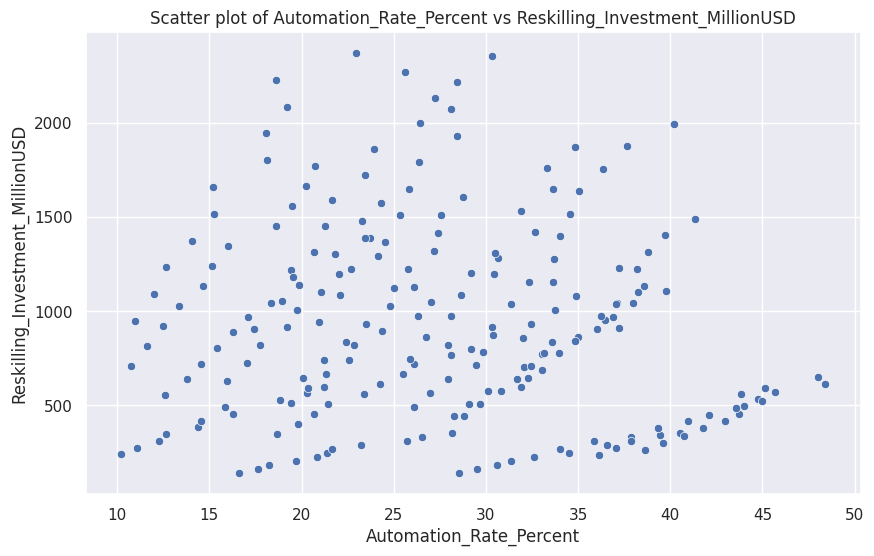

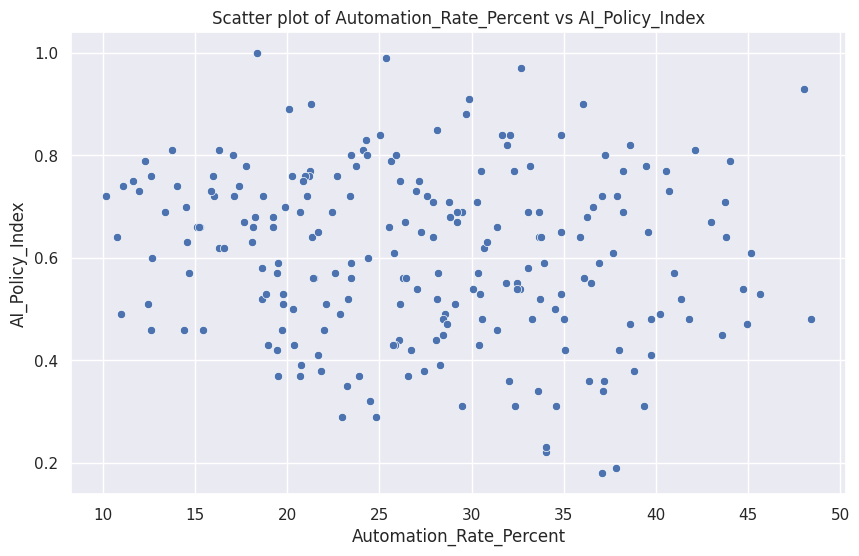

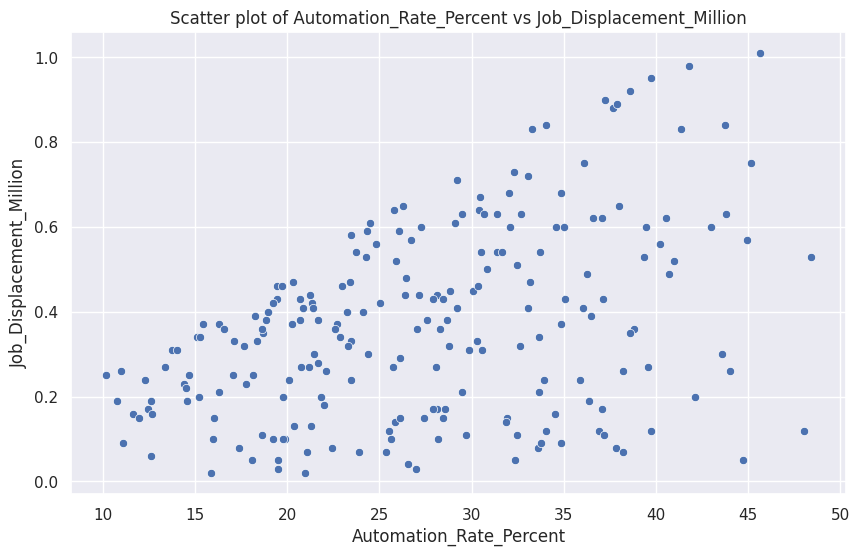

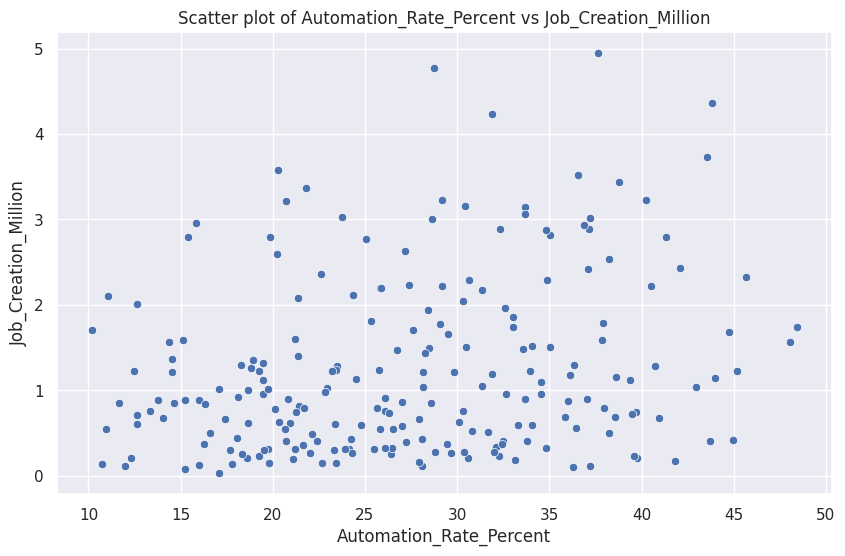

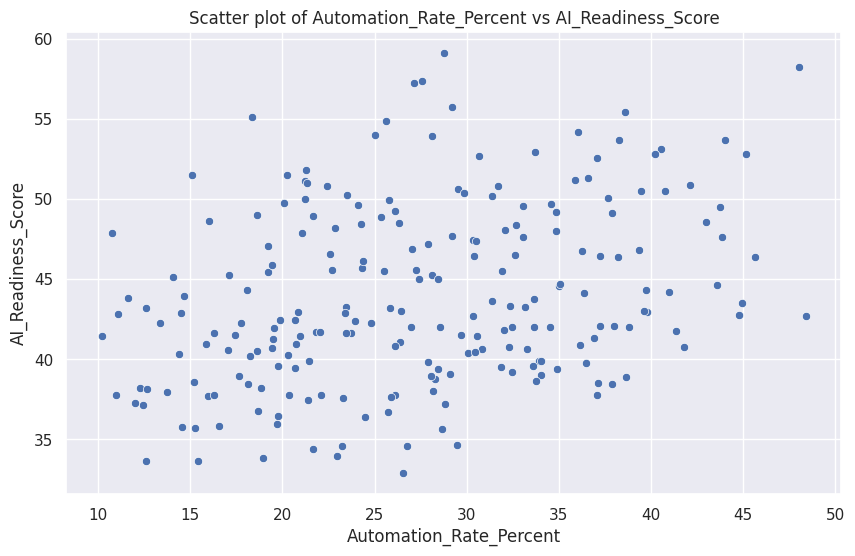

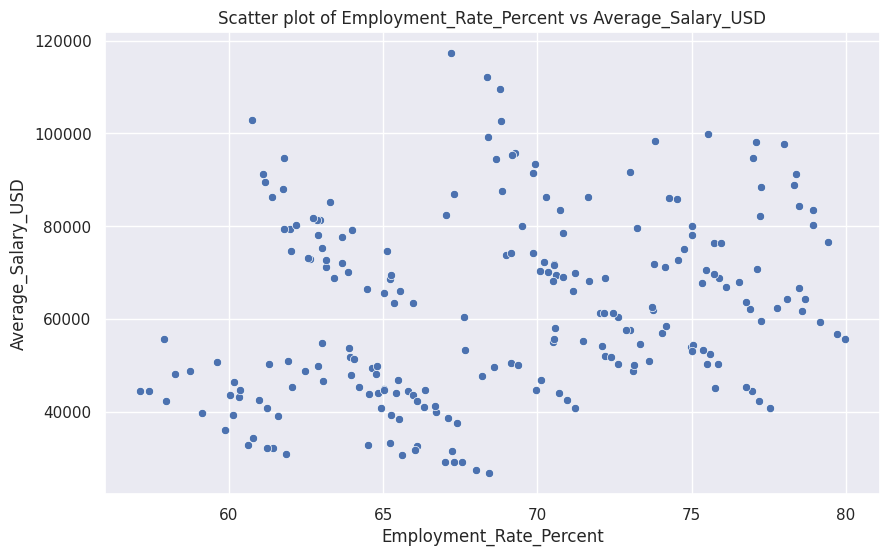

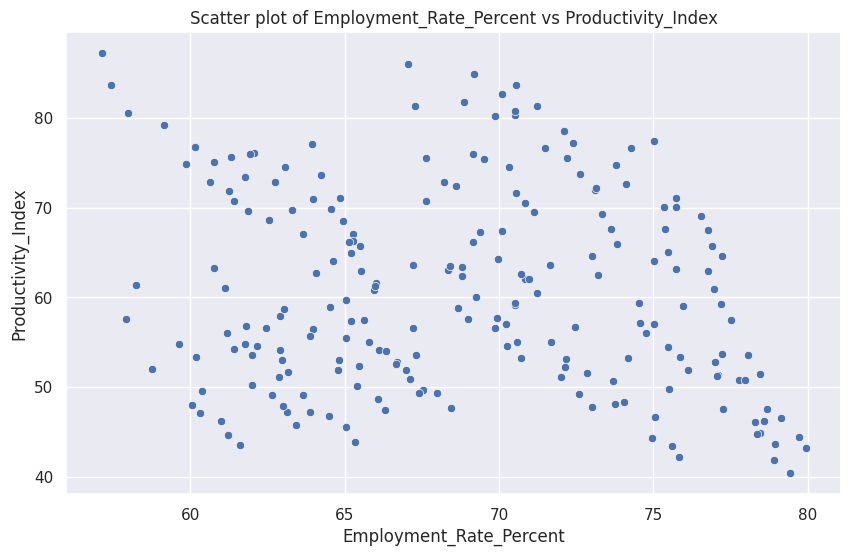

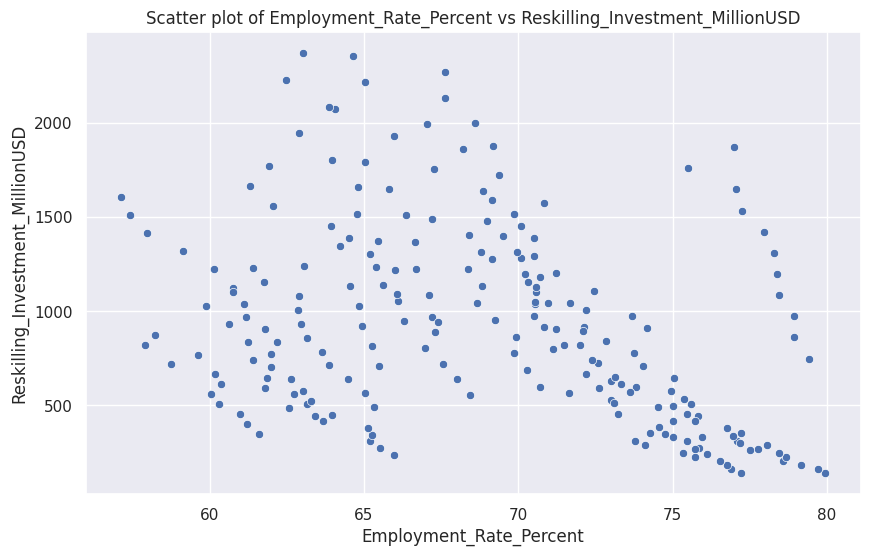

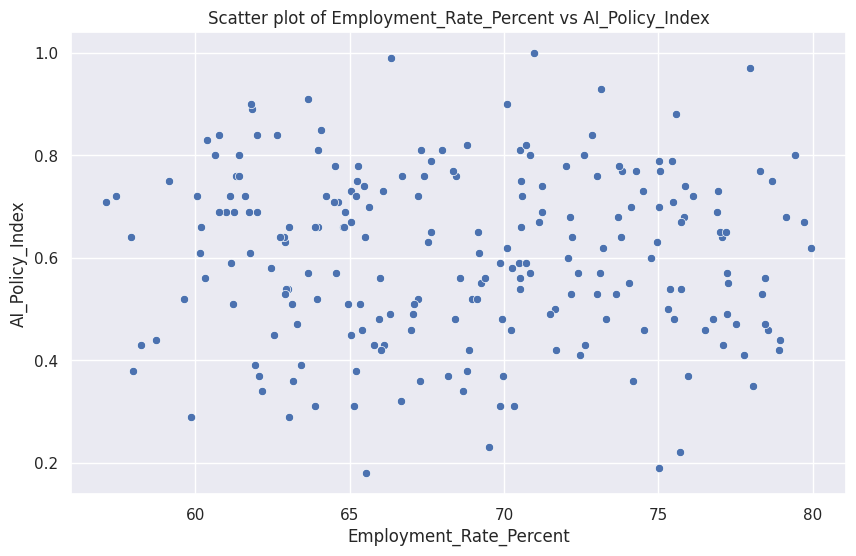

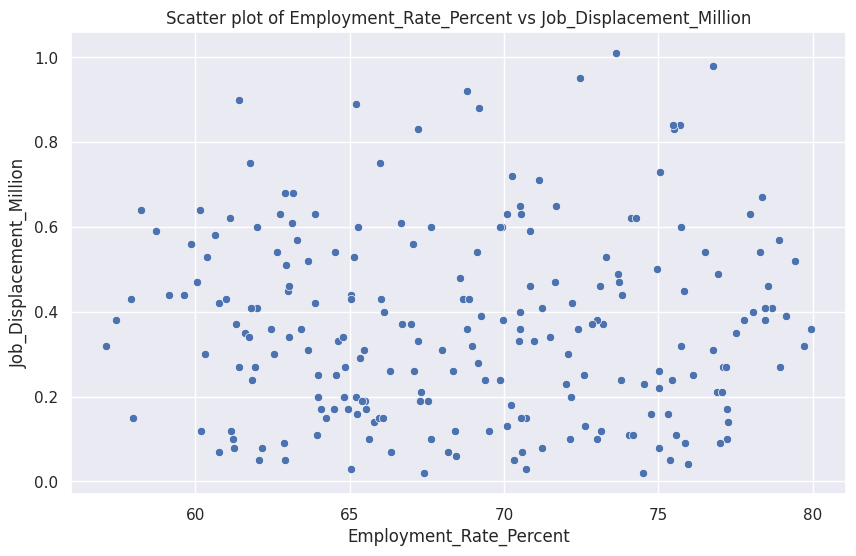

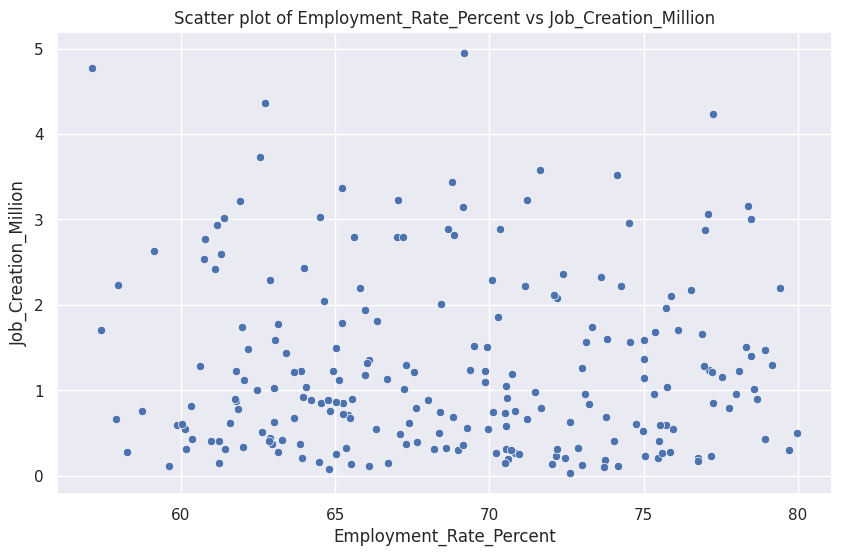

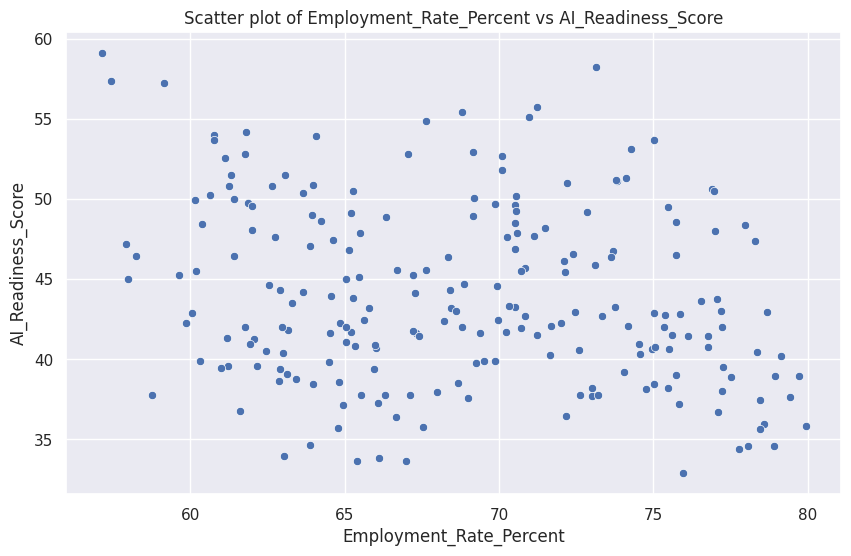

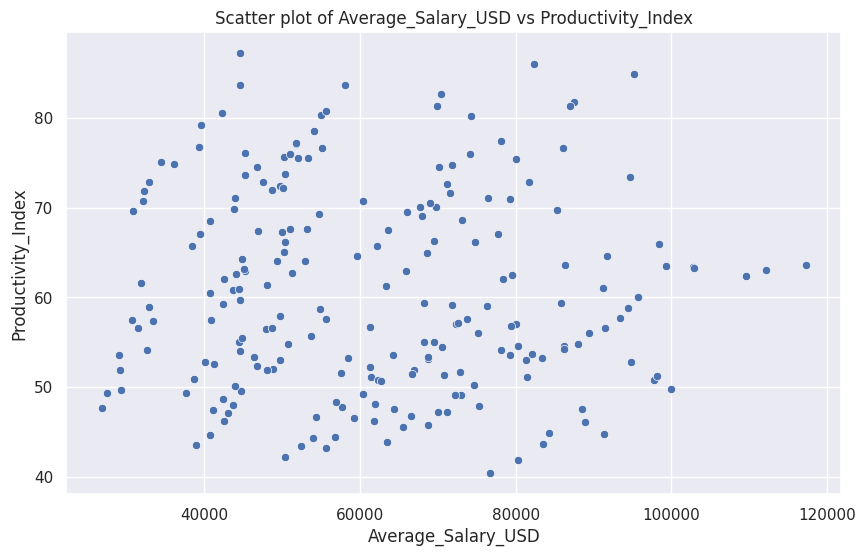

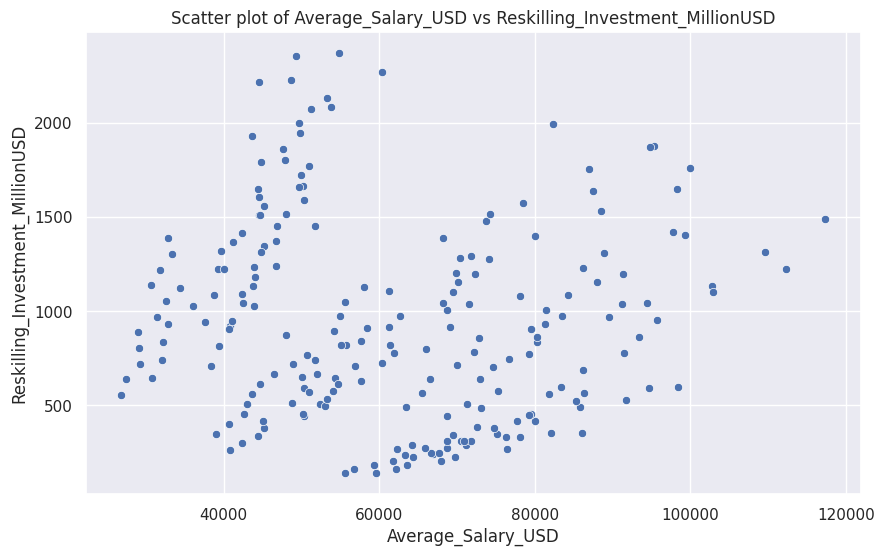

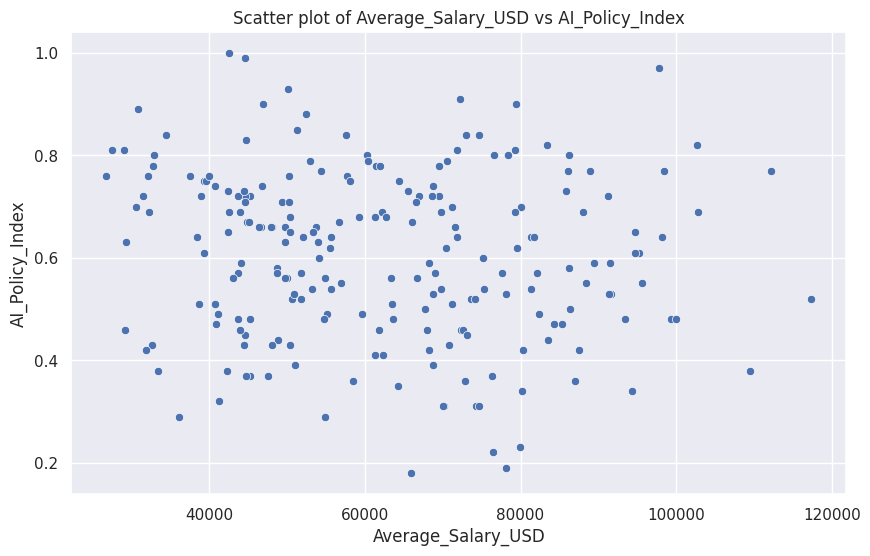

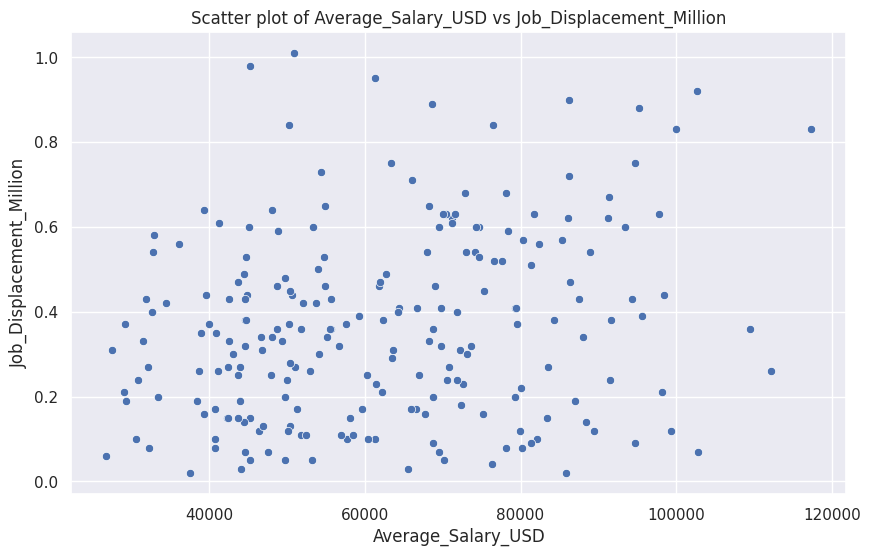

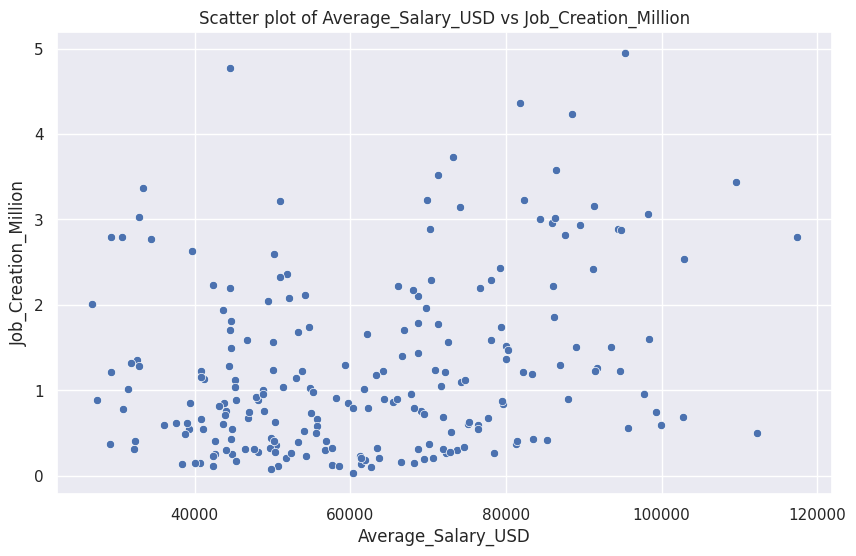

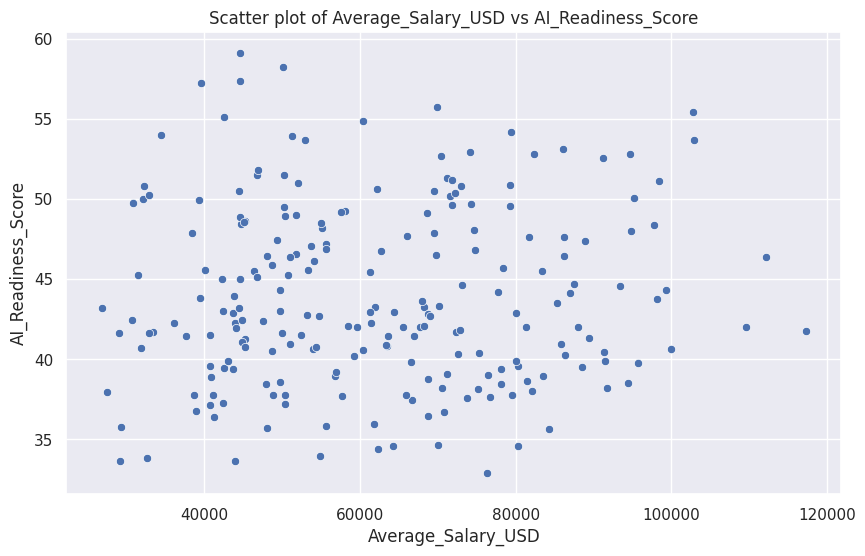

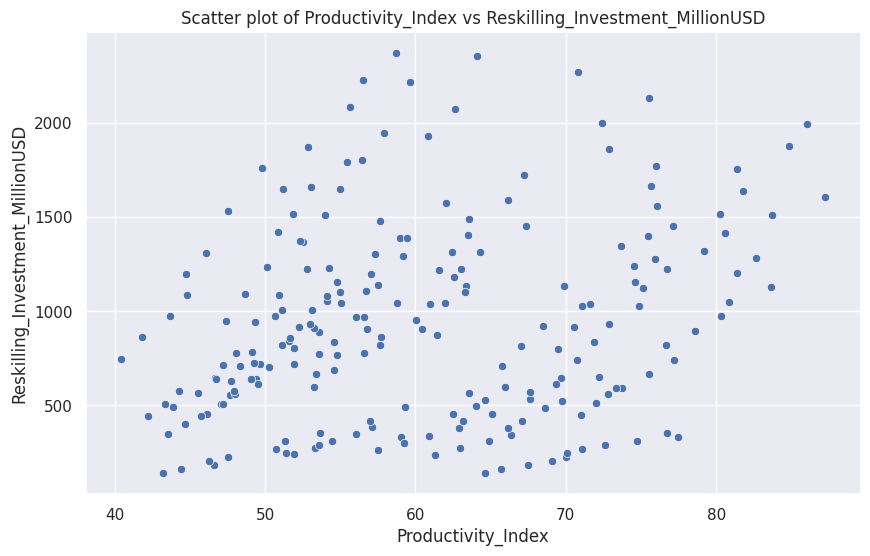

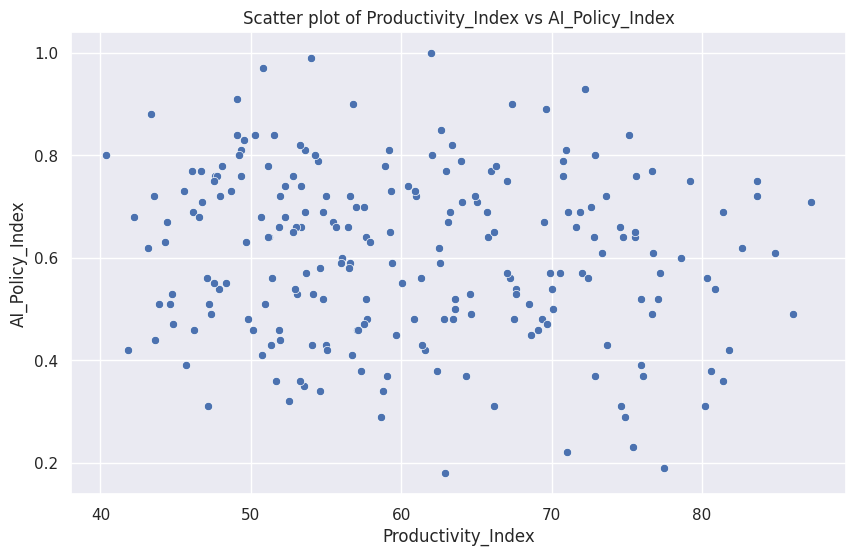

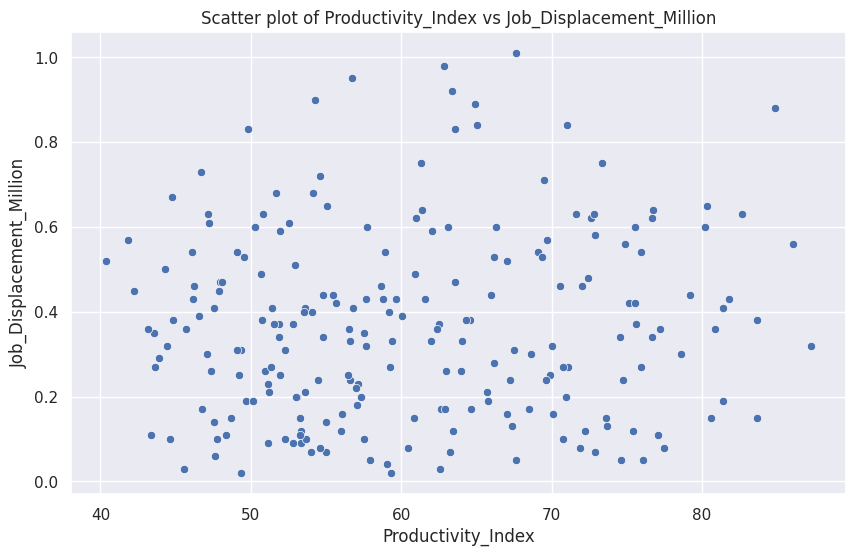

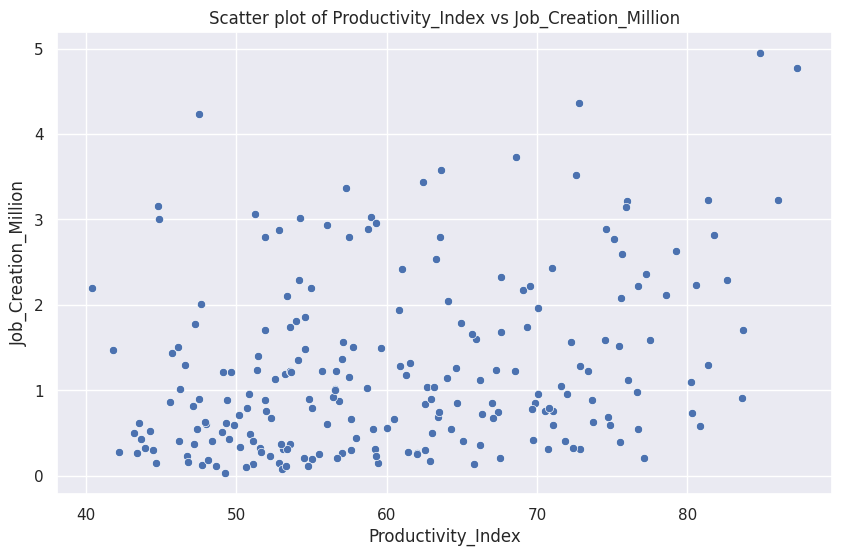

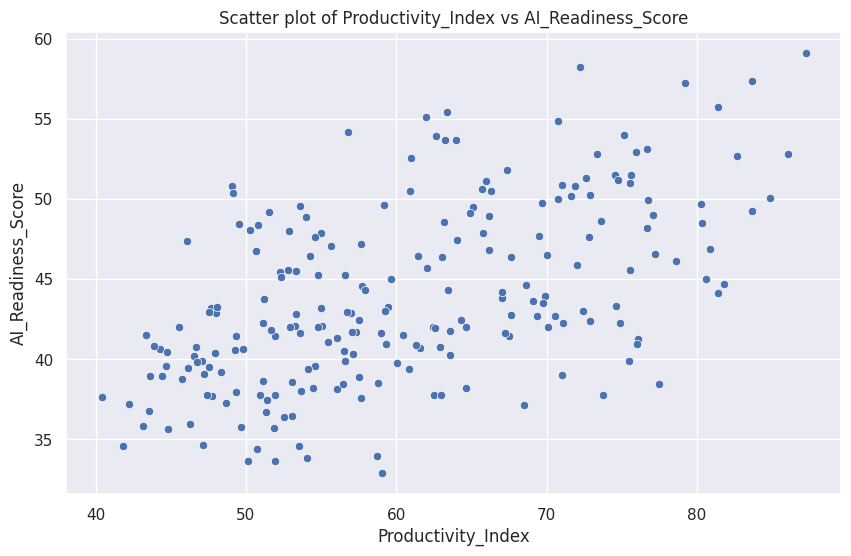

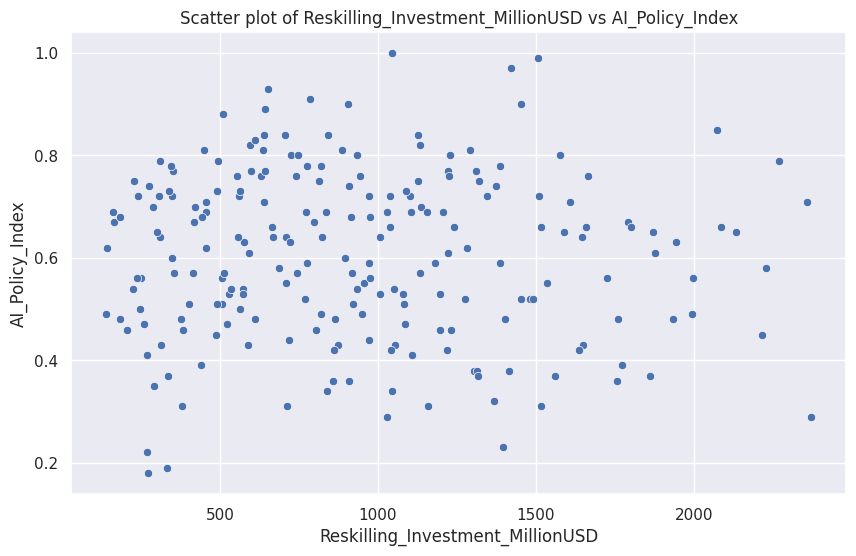

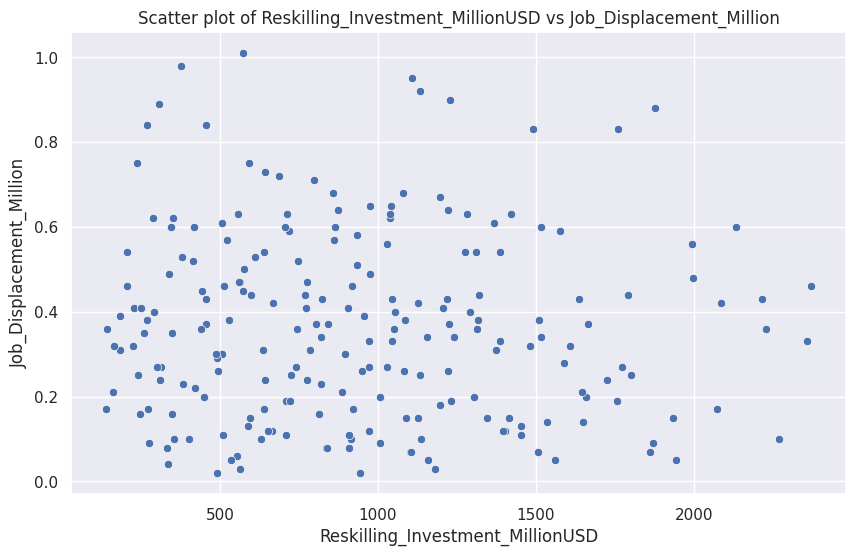

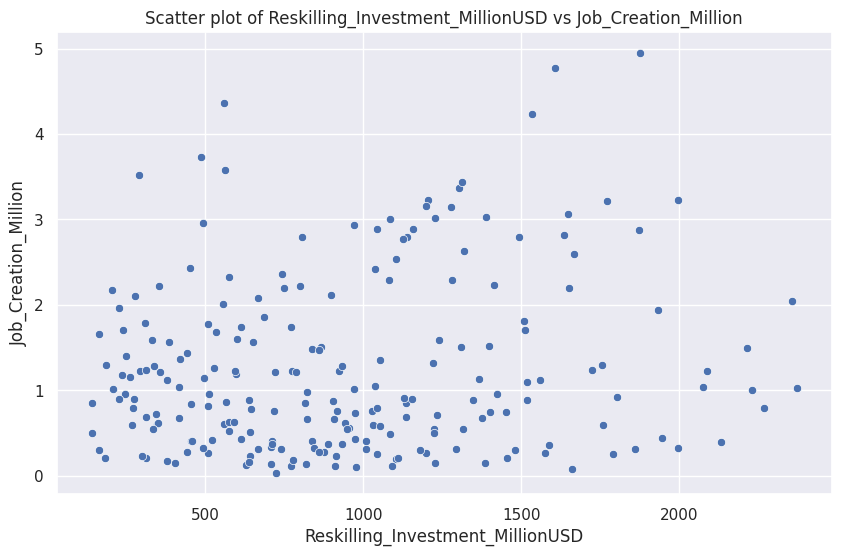

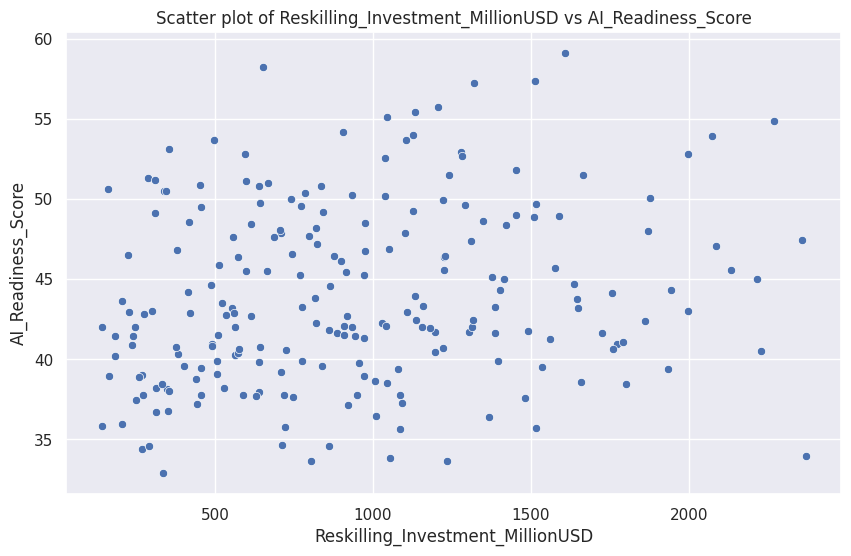

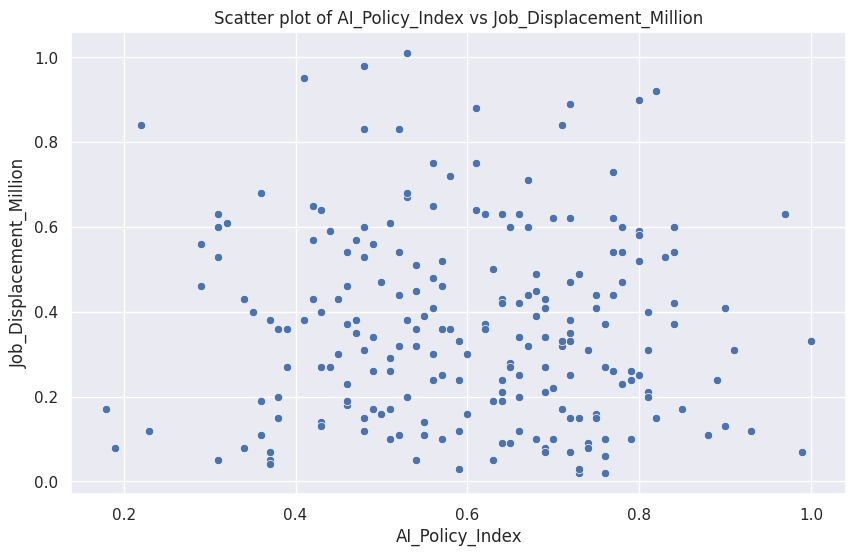

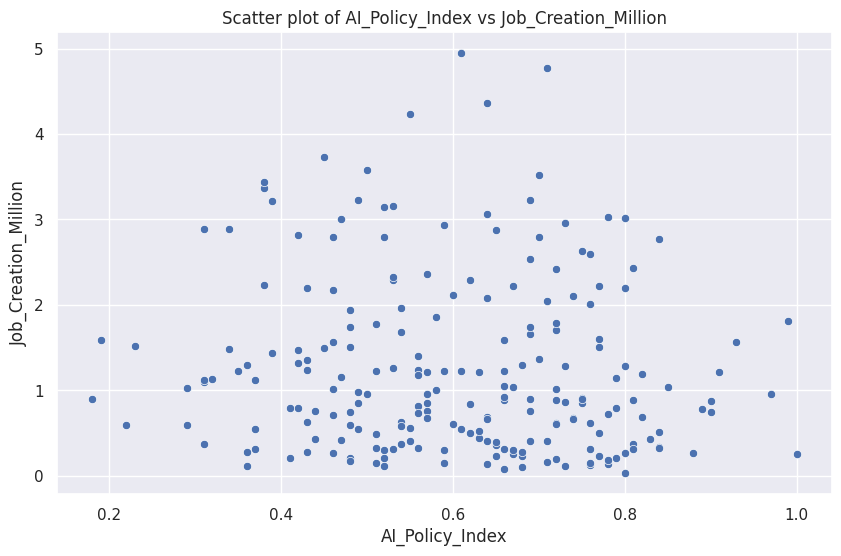

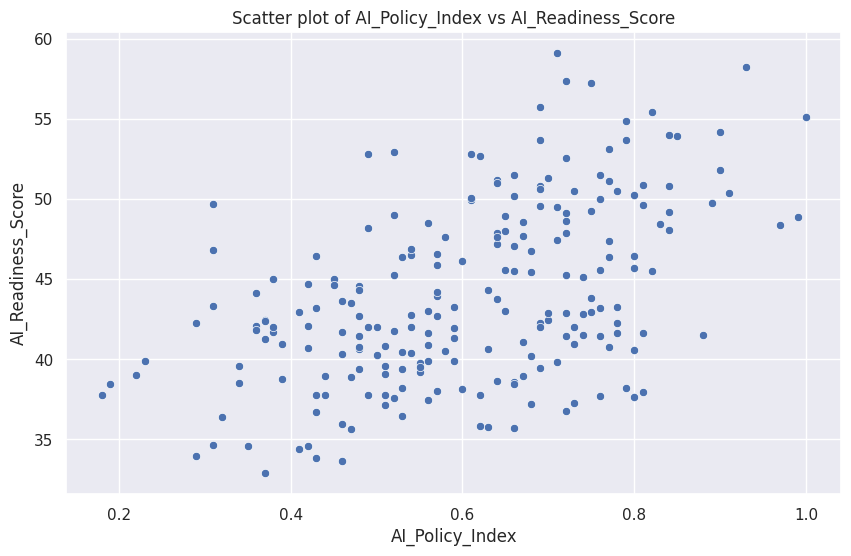

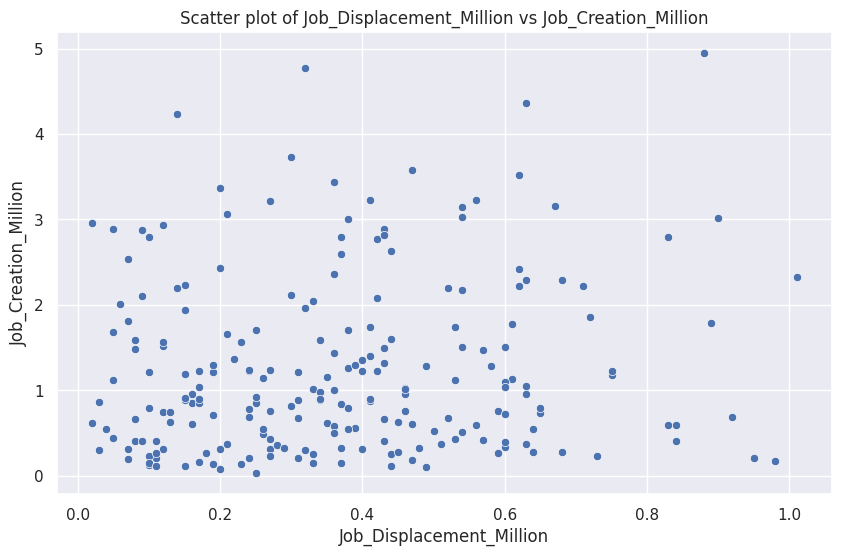

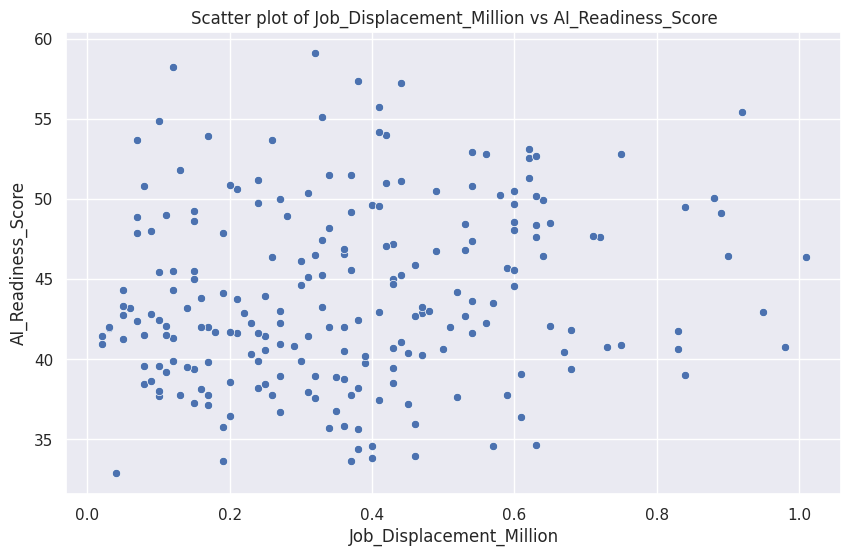

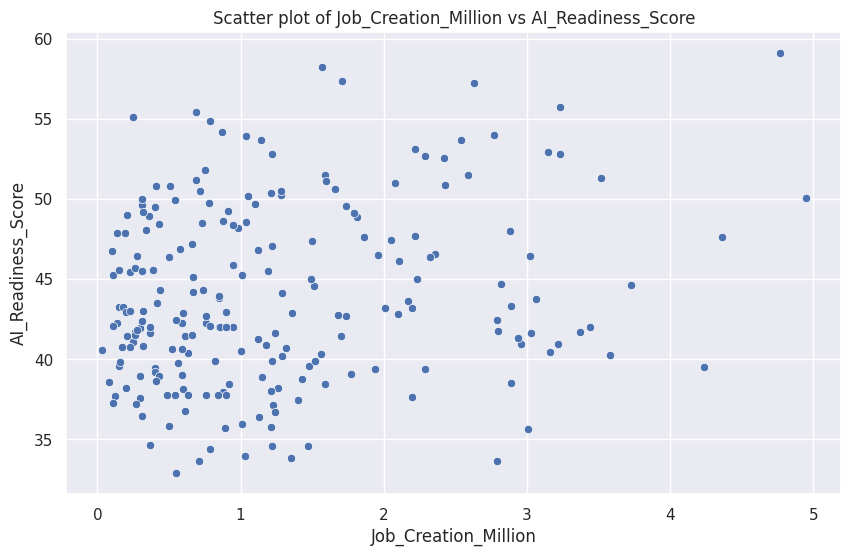

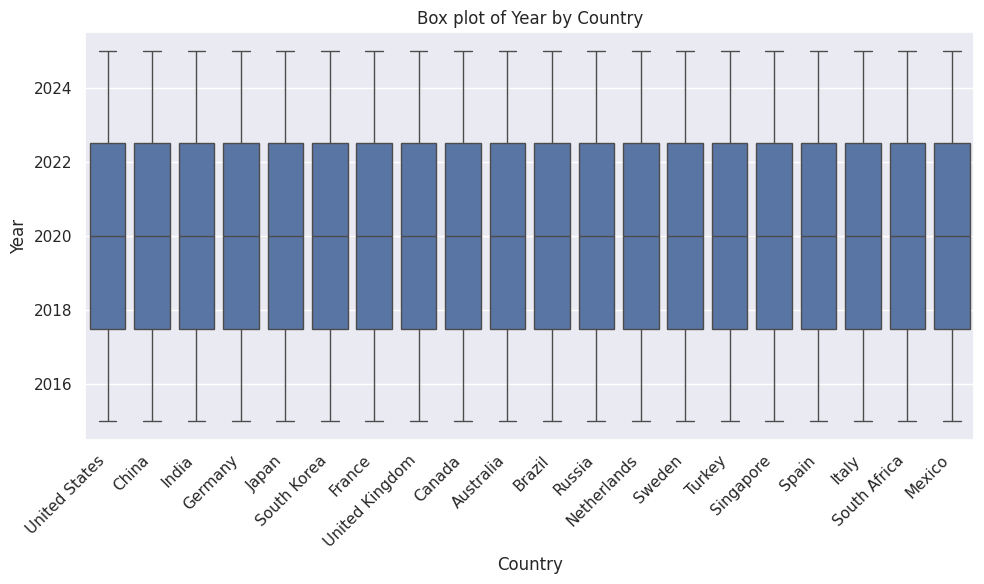

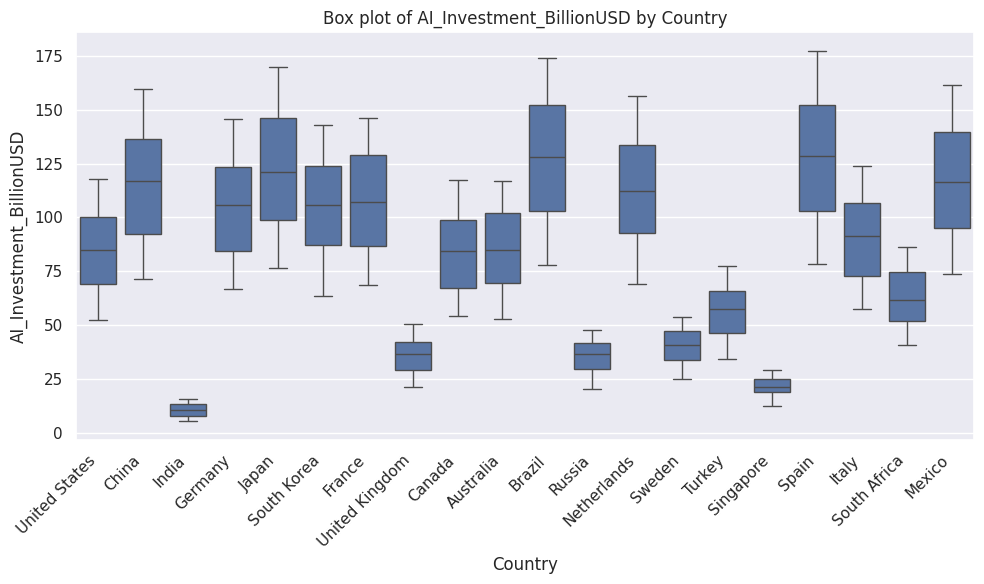

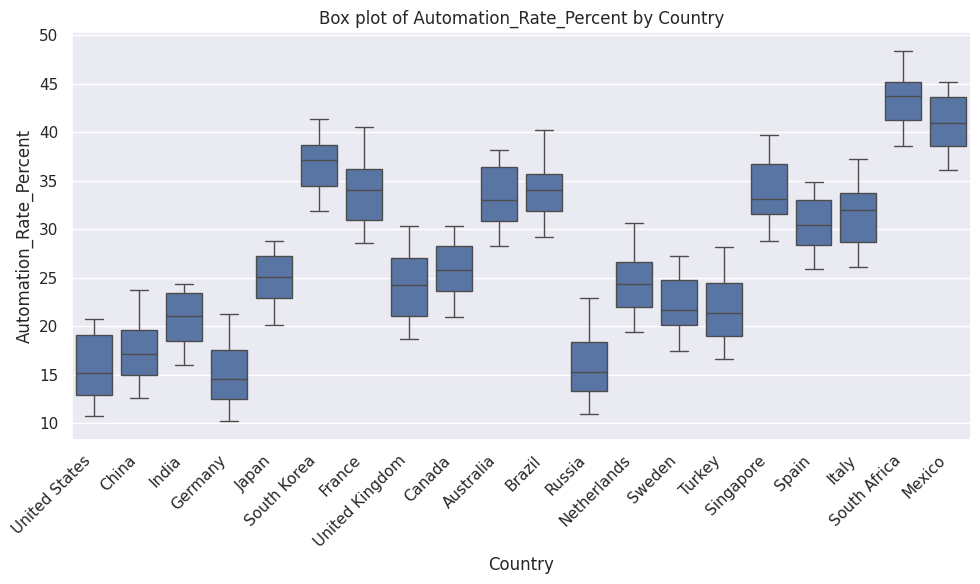

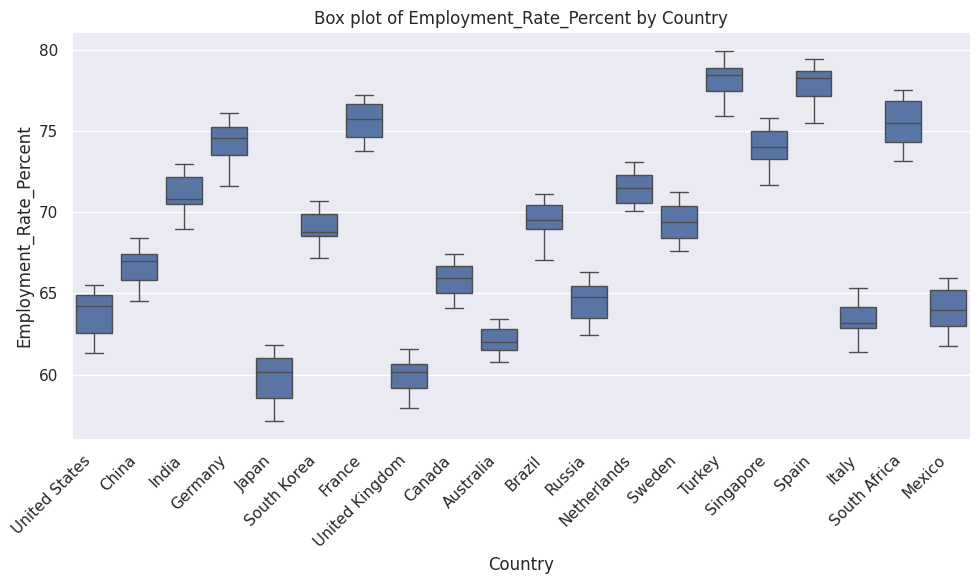

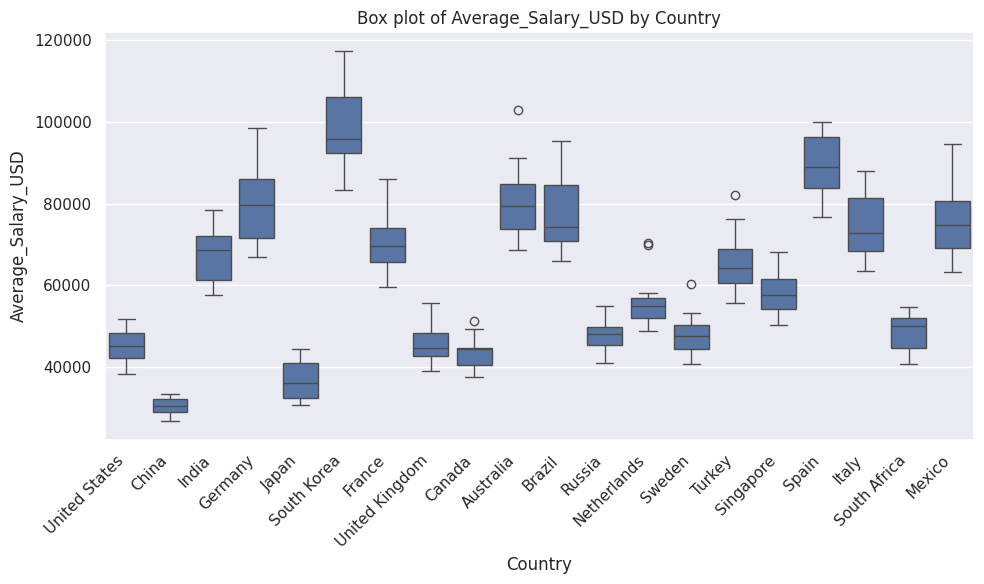

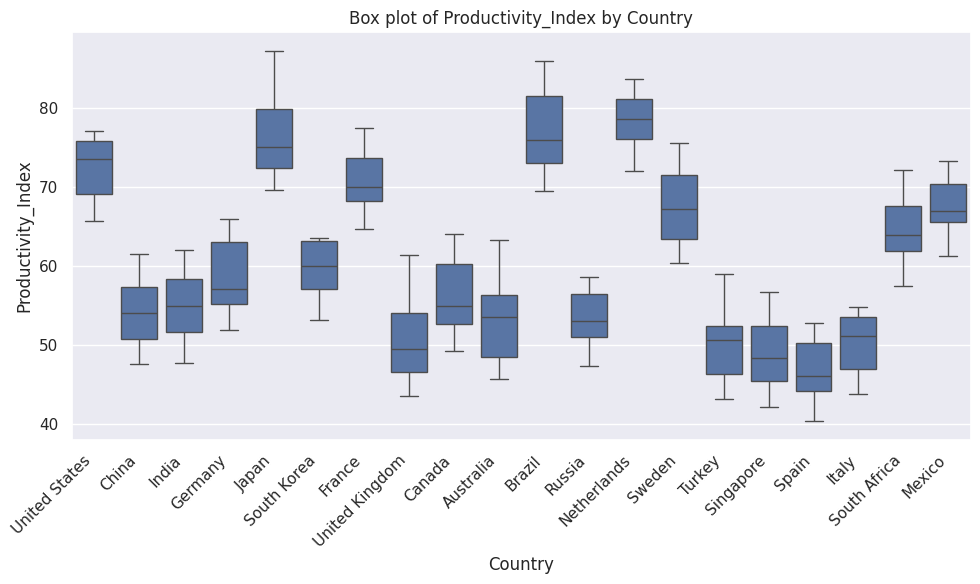

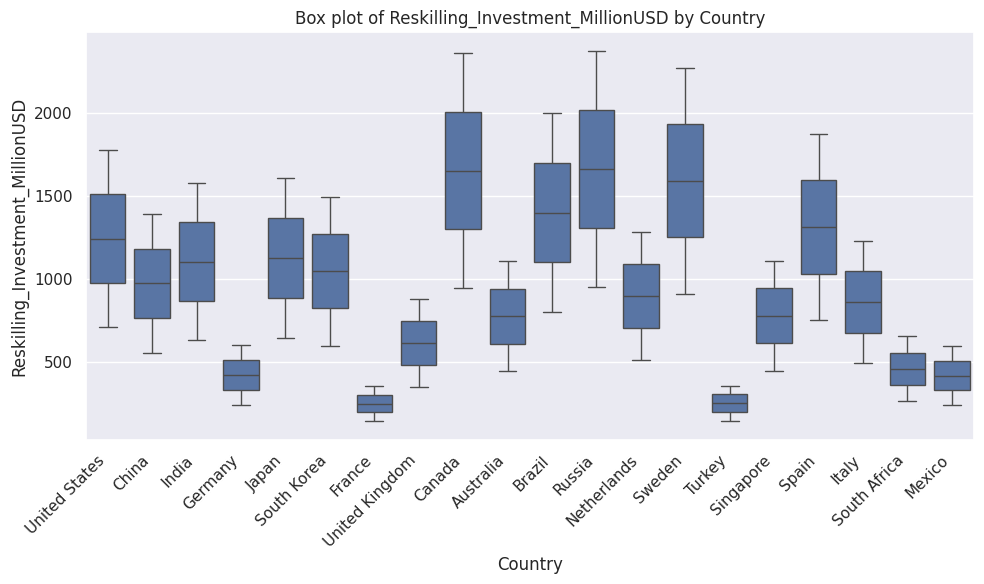

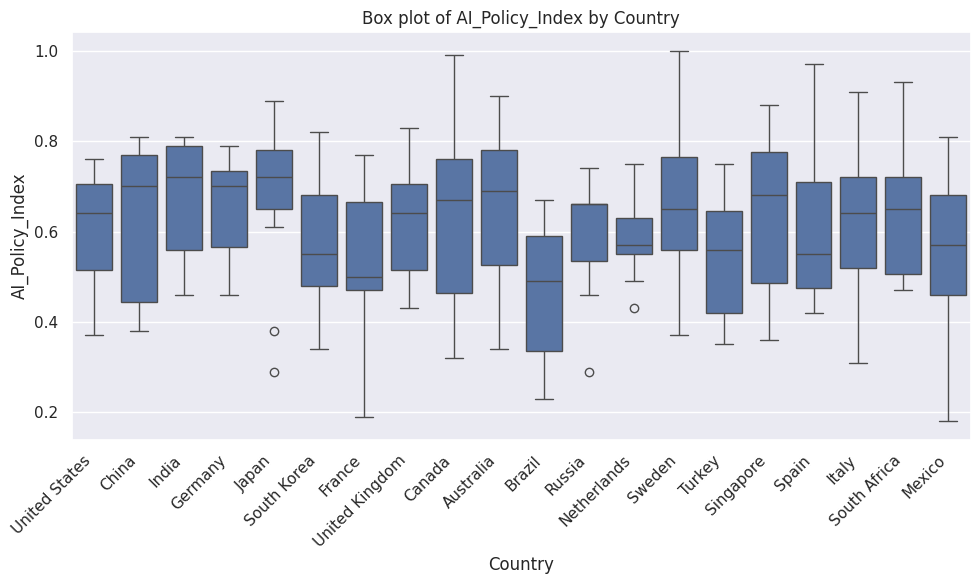

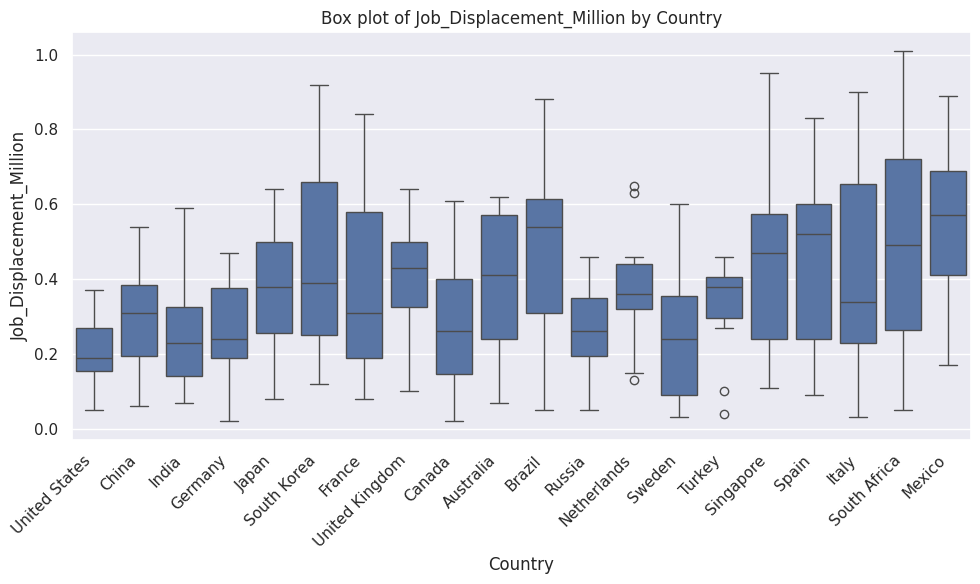

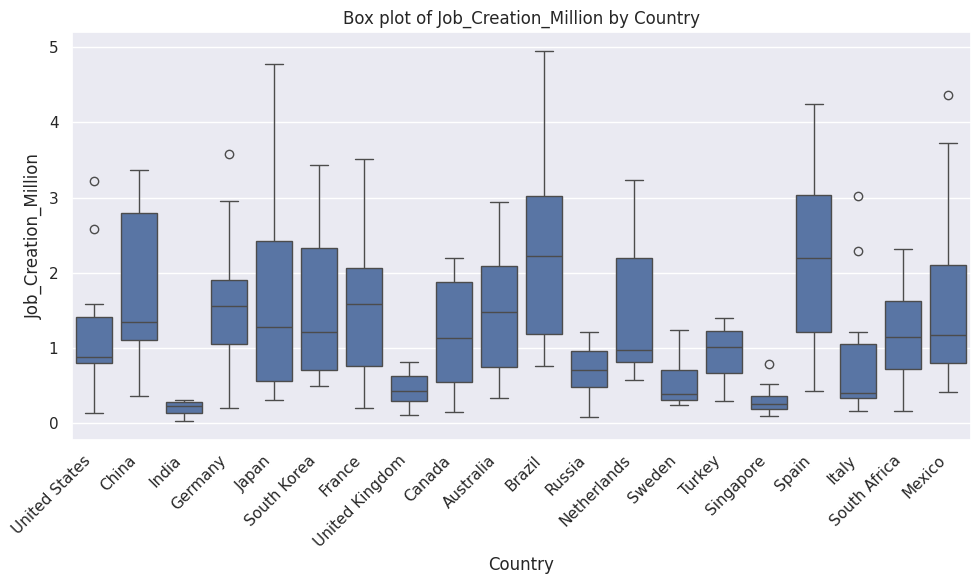

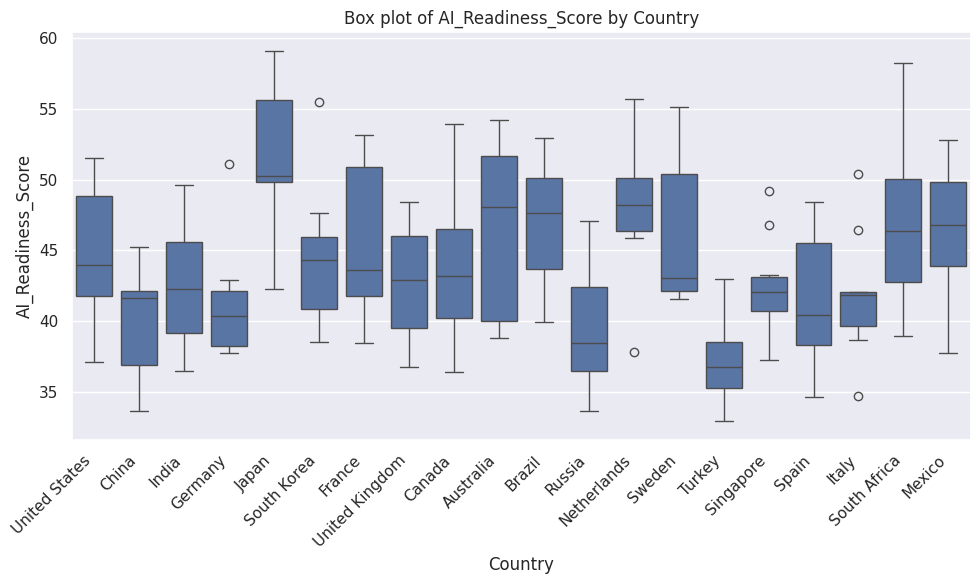

In [17]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

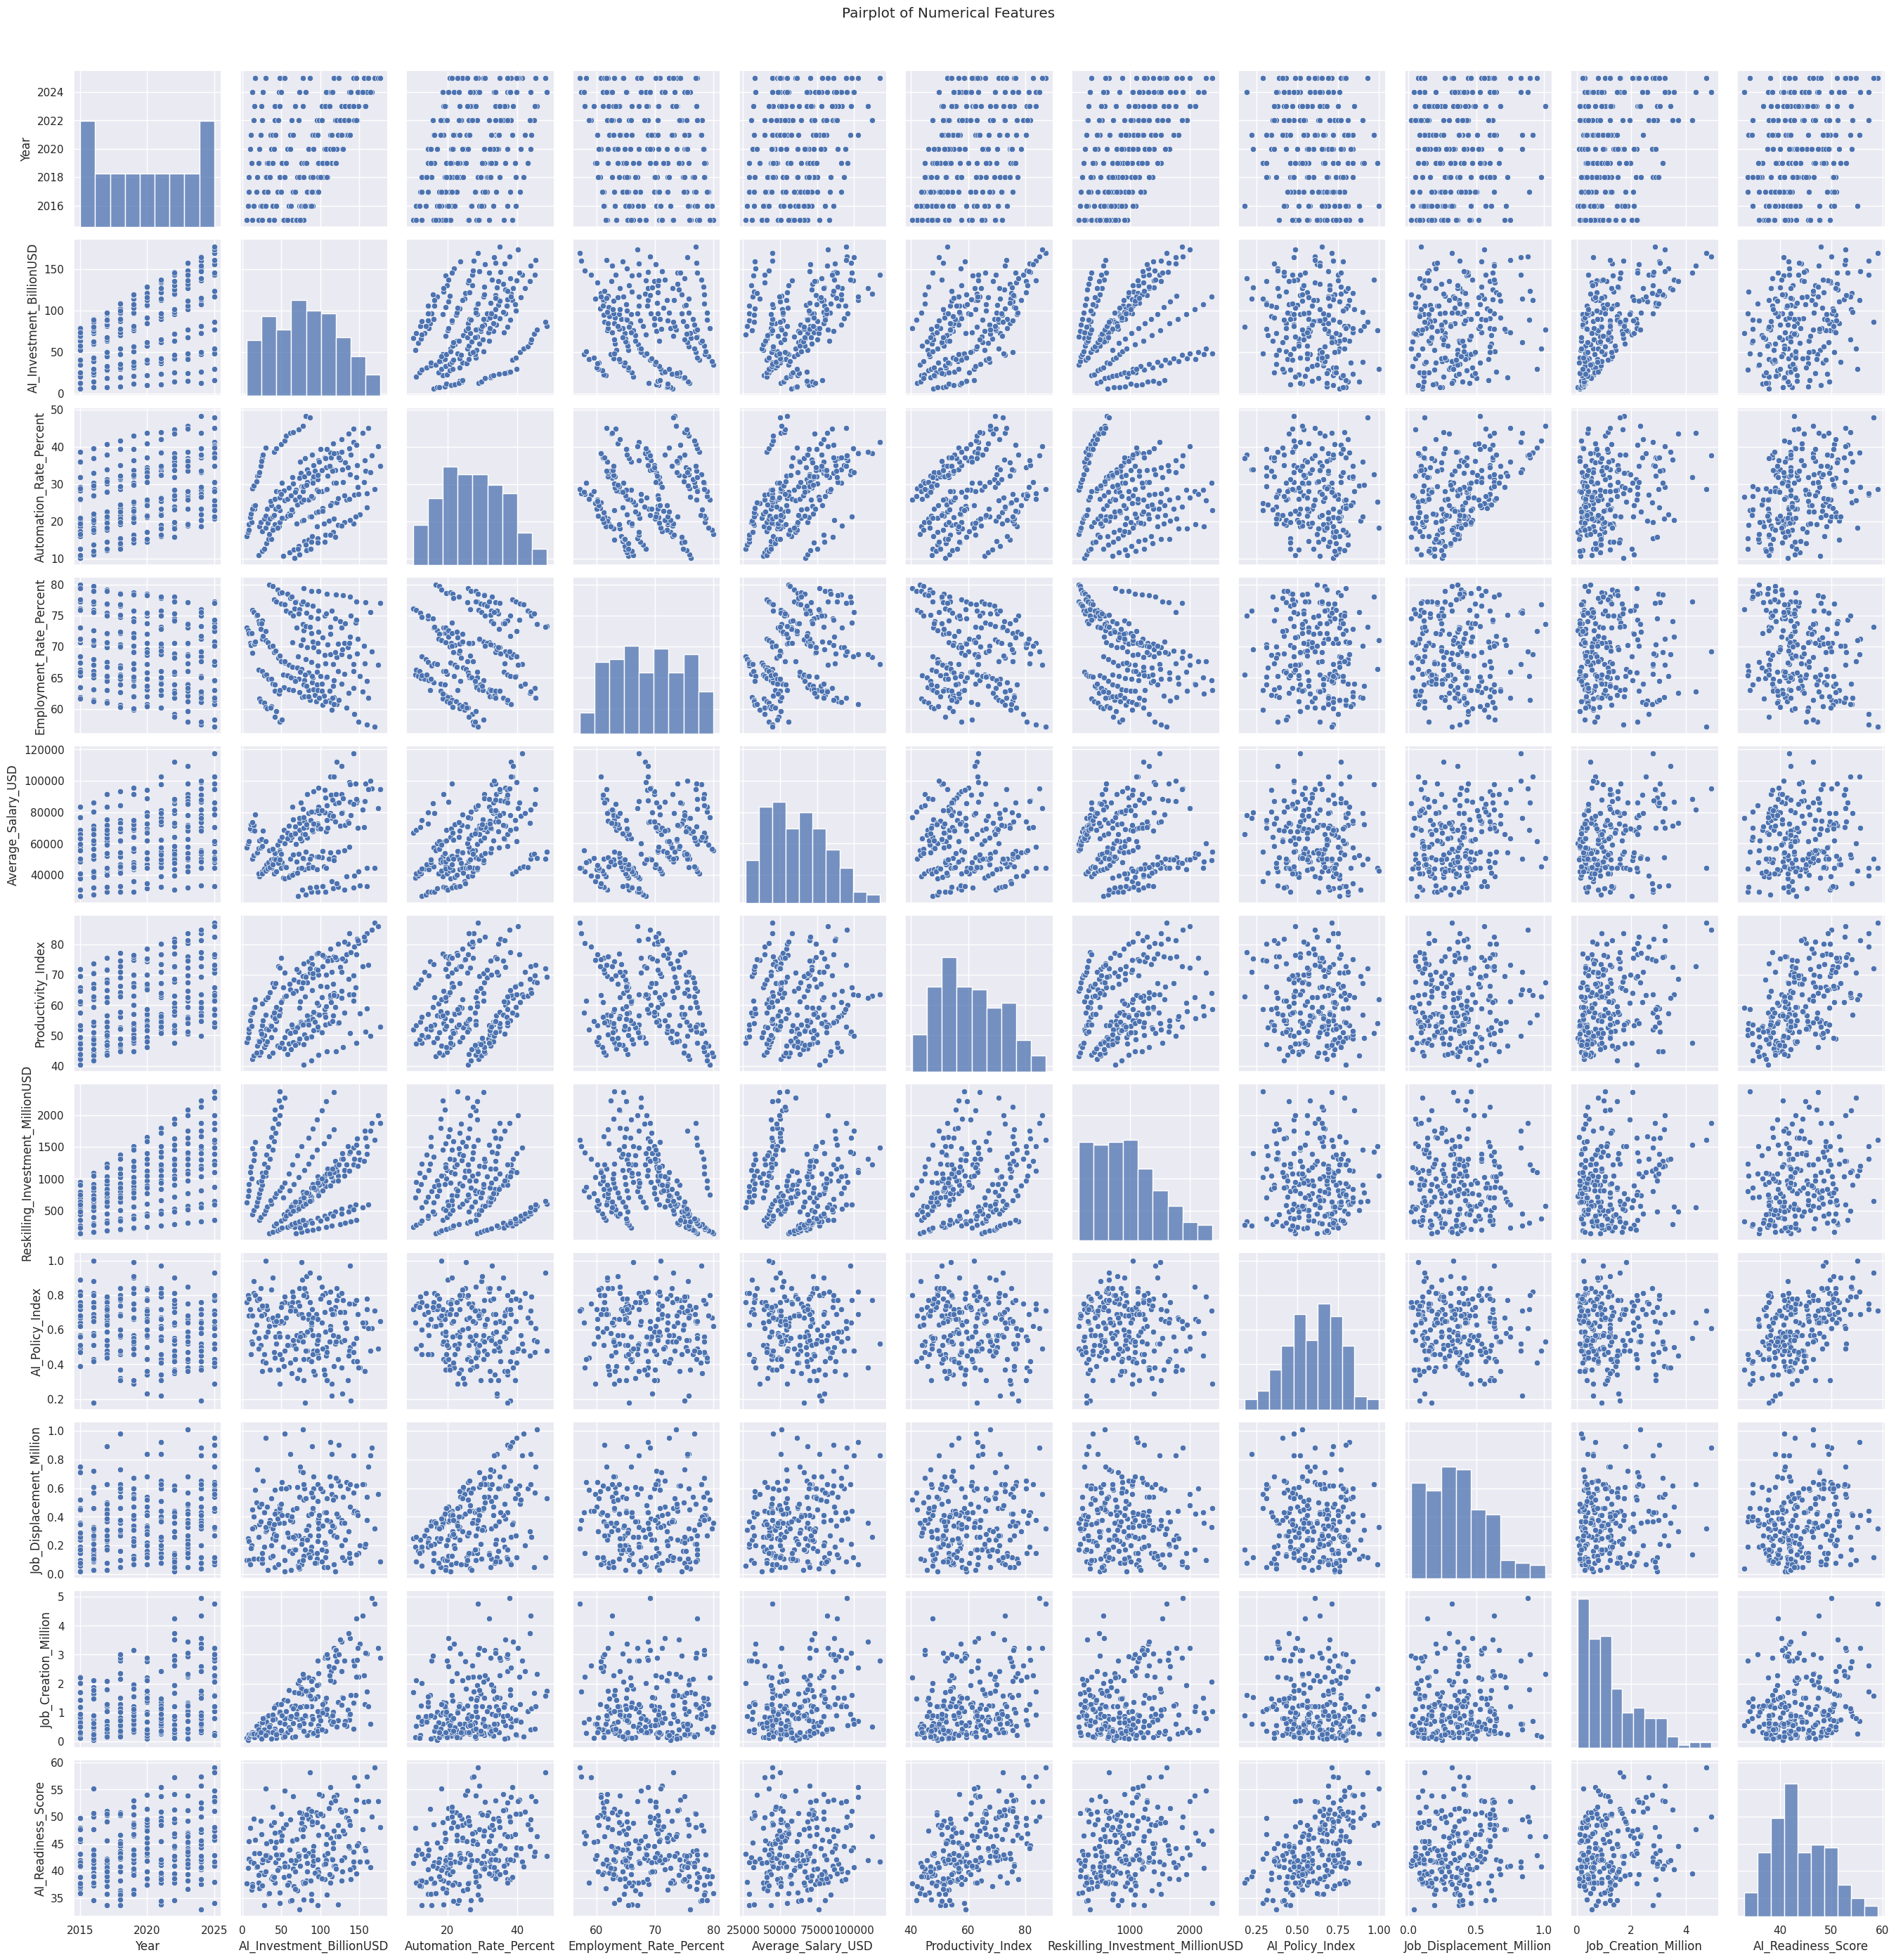

In [20]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

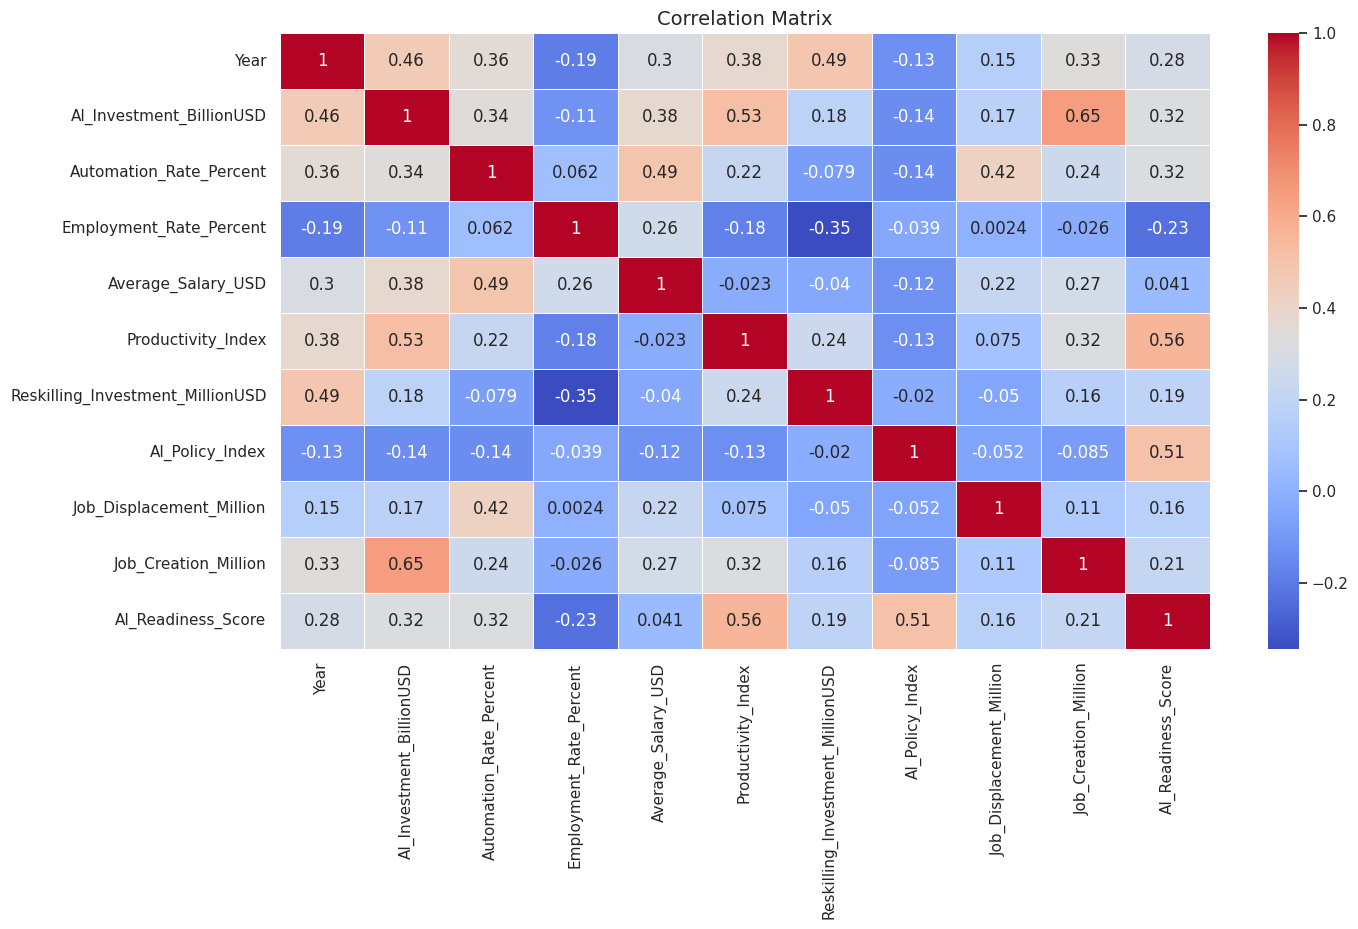

In [19]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You